# Visual Concept Learning Across Symbolic and Object-Like Categories

**Author:** Reza Mahin Mohammadalizadeh

## Project Overview

This project investigates how convolutional neural networks learn visual concepts and develop internal representations across different types of visual categories.

The analysis is based on two visual domains:

- **EMNIST Letters**, representing symbolic handwritten characters.
- **Fashion-MNIST**, representing more object-like visual categories.

The goal is not only to train accurate image classifiers, but also to analyze how visual information is transformed across the model hierarchy, how internal representations become organized, and how robust these learned representations are under noisy or adversarial conditions.

## Research Questions

This notebook addresses the following research questions:

**RQ1.** How do architecture and training hyperparameters affect visual concept learning performance?

**RQ2.** Do deeper layers of a convolutional neural network produce more linearly separable representations?

**RQ3.** Does the internal geometry of the learned representations reflect similarity between visual categories?

**RQ4.** Are classification errors random, or do they follow meaningful visual patterns?

**RQ5.** How robust are learned visual concepts to sensory noise and adversarial perturbations?

## Methodological Summary

The project follows a structured experimental workflow:

1. **Dataset preparation**  
   EMNIST Letters and Fashion-MNIST are loaded, preprocessed, normalized, and divided into training, validation, and test sets.

2. **Model selection**  
   Several compact convolutional neural network configurations are compared by varying architectural and training hyperparameters such as model width, dropout, learning rate, and weight decay.

3. **Final model training**  
   A selected CNN architecture is trained and evaluated using separate validation and test data.

4. **Linear read-out analysis**  
   Linear classifiers are trained on representations extracted from different levels of the network hierarchy. This tests whether deeper layers produce more disentangled and linearly separable visual representations.

5. **Representation analysis**  
   Internal representations are analyzed using representational similarity, hierarchical clustering, and silhouette scores to examine whether the model organizes categories according to meaningful visual similarity.

6. **Feature and activation visualization**  
   First-layer filters and activation maps are visualized to inspect what kinds of visual features are learned by the network.

7. **Error analysis**  
   Confusion matrices are used to identify systematic classification errors and determine whether misclassifications occur between visually similar categories.

8. **Psychometric curves**  
   The model is tested under increasing levels of Gaussian noise to measure how classification performance degrades as visual input becomes less reliable.

9. **Adversarial robustness**  
   FGSM-style adversarial perturbations are used to test the vulnerability of the model. A compact adversarial fine-tuning experiment is also included to evaluate whether robustness can be improved.

10. **Critical discussion**  
    The final results are interpreted in relation to representation learning, hierarchical processing, robustness, and computational models of visual cognition.

## Main Idea

A convolutional neural network can be interpreted not only as a classifier, but also as a hierarchical system that progressively transforms visual inputs into more abstract internal representations.

Early layers tend to encode local visual features such as edges and simple patterns, while deeper layers are expected to encode more category-relevant information. If this transformation is successful, deeper representations should become more linearly separable, more structured by category similarity, and more informative for classification.

This notebook tests that idea through classification performance, linear read-outs, representation geometry, clustering, error analysis, noise sensitivity, and adversarial robustness.

In [ ]:
# ============================================================
# Experimental setup
# ============================================================

from pathlib import Path
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

# ------------------------------------------------------------
# Dataset path
# ------------------------------------------------------------
PROJECT_ROOT = Path.cwd() 
DATA_DIR = PROJECT_ROOT / "Data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Device selection
# ------------------------------------------------------------
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(SEED)

# ------------------------------------------------------------
# Report setup
# ------------------------------------------------------------
print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)
print("Device:", DEVICE)
print("PyTorch version:", torch.__version__)
print("Random seed:", SEED)

Project root: /Users/reza/Desktop/Cognition and Computation/Project/visual-concept-learning:/Notebook
Data directory: /Users/reza/Desktop/Cognition and Computation/Project/visual-concept-learning:/Notebook/Data
Device: mps
PyTorch version: 2.8.0
Random seed: 42


## Dataset preprocessing

Both datasets contain grayscale images of size 28 × 28. The images are converted to tensors and normalized before being passed to the CNN. EMNIST images are corrected for orientation because the TorchVision version is rotated/flipped relative to normal visual display.

In [71]:
# ============================================================
# Dataset preprocessing
# ============================================================

from torchvision import datasets, transforms

emnist_transform = transforms.Compose([
    transforms.Lambda(lambda img: transforms.functional.rotate(img, -90)),
    transforms.Lambda(lambda img: transforms.functional.hflip(img)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

fashion_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

print("Dataset transforms defined.")

Dataset transforms defined.


## Dataset loading

The datasets are downloaded automatically through TorchVision. EMNIST Letters is used as the main symbolic visual-concept dataset, while Fashion-MNIST is used as a secondary object-like comparison dataset.

In [72]:
# ============================================================
# Dataset loading
# ============================================================

emnist_train_full = datasets.EMNIST(
    root=DATA_DIR,
    split="letters",
    train=True,
    download=True,
    transform=emnist_transform
)

emnist_test = datasets.EMNIST(
    root=DATA_DIR,
    split="letters",
    train=False,
    download=True,
    transform=emnist_transform
)

fashion_train_full = datasets.FashionMNIST(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=fashion_transform
)

fashion_test = datasets.FashionMNIST(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=fashion_transform
)

print("EMNIST Letters train:", len(emnist_train_full))
print("EMNIST Letters test:", len(emnist_test))
print("Fashion-MNIST train:", len(fashion_train_full))
print("Fashion-MNIST test:", len(fashion_test))

EMNIST Letters train: 124800
EMNIST Letters test: 20800
Fashion-MNIST train: 60000
Fashion-MNIST test: 10000


The datasets were loaded successfully. EMNIST Letters contains 124,800 training images and 20,800 test images across 26 letter classes. Fashion-MNIST contains 60,000 training images and 10,000 test images across 10 object-like classes. The larger number of EMNIST classes makes it the main dataset for the representational analyses, while Fashion-MNIST is used as a secondary comparison domain.

In [73]:
# ============================================================
# Class labels
# ============================================================

emnist_classes = [chr(ord("A") + i) for i in range(26)]

fashion_classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

print("EMNIST classes:")
print(emnist_classes)

print("\nFashion-MNIST classes:")
print(fashion_classes)

EMNIST classes:
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']

Fashion-MNIST classes:
['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## EMNIST label correction

TorchVision stores EMNIST Letters labels as integers from 1 to 26, corresponding to A–Z. For neural network training with `CrossEntropyLoss`, class labels must start from 0. Therefore, the EMNIST labels are shifted from 1–26 to 0–25.

In [74]:
# ============================================================
# EMNIST label correction
# ============================================================

class LabelShiftDataset(torch.utils.data.Dataset):
    """
    Shifts dataset labels by a fixed integer value.
    Used here to convert EMNIST Letters labels from 1-26 to 0-25.
    """
    def __init__(self, dataset, label_shift=-1):
        self.dataset = dataset
        self.label_shift = label_shift

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        image, label = self.dataset[index]
        label = label + self.label_shift
        return image, label


emnist_train_full = LabelShiftDataset(emnist_train_full, label_shift=-1)
emnist_test = LabelShiftDataset(emnist_test, label_shift=-1)

image, label = emnist_train_full[0]

print("Sample image shape:", image.shape)
print("Shifted label:", label)
print("Corresponding class:", emnist_classes[label])

Sample image shape: torch.Size([1, 28, 28])
Shifted label: 22
Corresponding class: W


## Train/validation/test protocol

For each dataset, the original training set is split into a training subset and a validation subset. The validation set is used for model selection and hyperparameter comparison, while the original test set is kept separate for final evaluation.

In [75]:
# ============================================================
# Train/validation split
# ============================================================

from torch.utils.data import DataLoader, random_split

BATCH_SIZE = 128
VAL_RATIO = 0.10

def create_train_val_split(dataset, val_ratio=0.10, seed=42):
    n_total = len(dataset)
    n_val = int(n_total * val_ratio)
    n_train = n_total - n_val

    generator = torch.Generator().manual_seed(seed)

    train_set, val_set = random_split(
        dataset,
        [n_train, n_val],
        generator=generator
    )

    return train_set, val_set


emnist_train, emnist_val = create_train_val_split(
    emnist_train_full,
    val_ratio=VAL_RATIO,
    seed=SEED
)

fashion_train, fashion_val = create_train_val_split(
    fashion_train_full,
    val_ratio=VAL_RATIO,
    seed=SEED
)

print("EMNIST train:", len(emnist_train))
print("EMNIST validation:", len(emnist_val))
print("EMNIST test:", len(emnist_test))

print("\nFashion-MNIST train:", len(fashion_train))
print("Fashion-MNIST validation:", len(fashion_val))
print("Fashion-MNIST test:", len(fashion_test))

EMNIST train: 112320
EMNIST validation: 12480
EMNIST test: 20800

Fashion-MNIST train: 54000
Fashion-MNIST validation: 6000
Fashion-MNIST test: 10000


The train/validation/test split was created successfully. For both datasets, 90% of the original training data is used for model training and 10% is used for validation. The test sets are kept separate and will only be used for final evaluation and analysis.

In [76]:
# ============================================================
# DataLoaders
# ============================================================

emnist_loaders = {
    "train": DataLoader(emnist_train, batch_size=BATCH_SIZE, shuffle=True),
    "val": DataLoader(emnist_val, batch_size=BATCH_SIZE, shuffle=False),
    "test": DataLoader(emnist_test, batch_size=BATCH_SIZE, shuffle=False)
}

fashion_loaders = {
    "train": DataLoader(fashion_train, batch_size=BATCH_SIZE, shuffle=True),
    "val": DataLoader(fashion_val, batch_size=BATCH_SIZE, shuffle=False),
    "test": DataLoader(fashion_test, batch_size=BATCH_SIZE, shuffle=False)
}

batch_images, batch_labels = next(iter(emnist_loaders["train"]))

print("One EMNIST batch image tensor shape:", batch_images.shape)
print("One EMNIST batch label tensor shape:", batch_labels.shape)
print("Minimum label in batch:", batch_labels.min().item())
print("Maximum label in batch:", batch_labels.max().item())

One EMNIST batch image tensor shape: torch.Size([128, 1, 28, 28])
One EMNIST batch label tensor shape: torch.Size([128])
Minimum label in batch: 0
Maximum label in batch: 25


The DataLoaders were created successfully. Each EMNIST batch has shape `(128, 1, 28, 28)`, corresponding to 128 grayscale images of size 28 × 28. The labels range from 0 to 25, confirming that the EMNIST label correction was applied correctly.

## Visual inspection of the datasets

Before training the models, a small set of samples is visualized from each dataset. This verifies that the images are correctly loaded, preprocessed, and oriented.

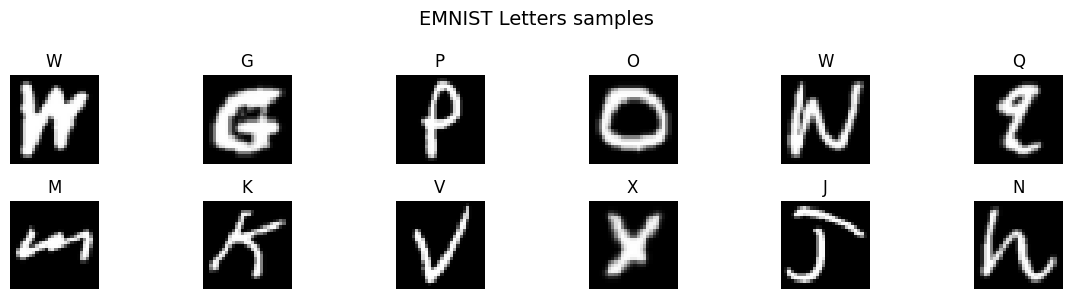

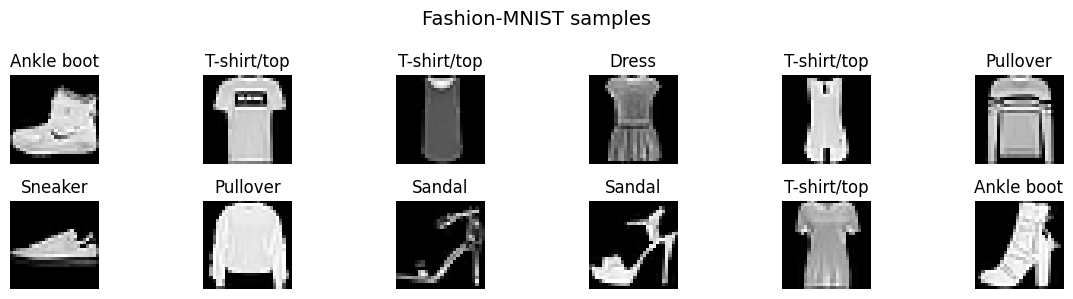

In [77]:
# ============================================================
# Dataset visualization
# ============================================================

def show_samples(dataset, class_names, title, n_samples=12):
    plt.figure(figsize=(12, 3))
    
    for i in range(n_samples):
        image, label = dataset[i]
        
        # Convert from normalized tensor [-1, 1] back to [0, 1]
        image = image.squeeze().numpy()
        image = (image * 0.5) + 0.5
        
        plt.subplot(2, 6, i + 1)
        plt.imshow(image, cmap="gray")
        plt.title(class_names[label])
        plt.axis("off")
    
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


show_samples(emnist_train_full, emnist_classes, "EMNIST Letters samples")
show_samples(fashion_train_full, fashion_classes, "Fashion-MNIST samples")

The visual inspection confirms that both datasets were loaded correctly. EMNIST samples are properly oriented after the rotation and horizontal flip correction, and the labels correspond to letters from A to Z. Fashion-MNIST samples show object-like clothing categories. These two datasets therefore provide two complementary domains for studying visual concept learning: symbolic handwritten characters and object-like visual categories.

## CNN architecture

The model used in this project is a compact hierarchical convolutional neural network. It is designed to learn visual representations at multiple levels: early convolutional layers extract low-level visual features, while deeper layers combine these features into more abstract category-level representations.

The architecture exposes intermediate feature representations, which will later be used for layer-wise linear read-outs and representational analysis.

### Architecture summary

| Stage | Operation | Output / interpretation |
|---|---|---|
| Input | 28 × 28 grayscale image | Raw visual input |
| Convolutional block 1 | Two convolutional layers, batch normalization, ReLU, max pooling | Extracts low-level local visual features such as strokes, edges, and simple contours; output shape: 32 × 14 × 14 |
| Convolutional block 2 | Deeper convolutional layers with more filters, batch normalization, ReLU, max pooling | Combines local features into more complex visual patterns; output shape: 64 × 7 × 7 |
| Convolutional block 3 | Final convolutional layer with increased feature channels, batch normalization, ReLU, adaptive average pooling. | Produces a compact high-level representation; output shape: 128 × 1 × 1. |
| Flattening | Converts the final 128 × 1 × 1 feature map into a 128-dimensional vector | Provides a compact high-level representation for classification and read-out analysis |
| Classifier | Fully connected output layer | Predicts the visual category |

This architecture is appropriate for the project because it creates a hierarchy of visual representations. Early layers process local sensory information, while deeper layers produce more abstract representations. The architecture test confirms that spatial resolution is progressively reduced from 28 × 28 to 14 × 14, then 7 × 7, and finally to a compact 1 × 1 high-level representation, while the number of feature channels increases from 1 to 32, 64, and 128. This makes it possible to test whether deeper representations become more linearly separable using read-outs, and to analyze the internal geometry of the learned feature space.

In [78]:
# ============================================================
# CNN architecture
# ============================================================

import torch.nn as nn
import torch.nn.functional as F

class VisualConceptCNN(nn.Module):
    """
    Compact CNN for 28x28 grayscale visual concept learning.

    The model returns both classification logits and intermediate
    representations when requested. These intermediate activations
    are later used for linear read-outs and representation analysis.
    """
    def __init__(self, num_classes, dropout=0.30, base_filters=32):
        super().__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1, base_filters, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_filters),
            nn.ReLU(),
            nn.Conv2d(base_filters, base_filters, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_filters),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(base_filters, base_filters * 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_filters * 2),
            nn.ReLU(),
            nn.Conv2d(base_filters * 2, base_filters * 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_filters * 2),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.conv_block3 = nn.Sequential(
            nn.Conv2d(base_filters * 2, base_filters * 4, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_filters * 4),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(base_filters * 4, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x, return_features=False):
        features = {}

        x = self.conv_block1(x)
        features["block1"] = x

        x = self.conv_block2(x)
        features["block2"] = x

        x = self.conv_block3(x)
        features["block3"] = x

        logits = self.classifier(x)

        if return_features:
            return logits, features

        return logits


# Quick architecture test
test_model = VisualConceptCNN(num_classes=26).to(DEVICE)
test_batch = batch_images.to(DEVICE)

with torch.no_grad():
    test_logits, test_features = test_model(test_batch, return_features=True)

print("Input batch shape:", test_batch.shape)
print("Output logits shape:", test_logits.shape)

for layer_name, feature_tensor in test_features.items():
    print(layer_name, "feature shape:", feature_tensor.shape)

Input batch shape: torch.Size([128, 1, 28, 28])
Output logits shape: torch.Size([128, 26])
block1 feature shape: torch.Size([128, 32, 14, 14])
block2 feature shape: torch.Size([128, 64, 7, 7])
block3 feature shape: torch.Size([128, 128, 1, 1])


The architecture test confirms that the CNN processes the input correctly. The model progressively reduces spatial resolution from 28 × 28 to 14 × 14, then 7 × 7, and finally to a compact 1 × 1 high-level representation. At the same time, the number of feature channels increases from 1 to 32, 64, and 128. This structure is suitable for studying hierarchical representation learning because intermediate activations can be extracted from each convolutional block.

## Training and evaluation functions

The following functions implement the training and evaluation loop. During training, the model parameters are updated using the training set. During evaluation, the model is tested without gradient updates on the validation or test set. Accuracy and macro-F1 score are reported because the project compares classification performance across different model variants.

In [79]:
# ============================================================
# Training and evaluation functions
# ============================================================

from sklearn.metrics import accuracy_score, f1_score
from tqdm.auto import tqdm
import torch.optim as optim

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    
    running_loss = 0.0
    all_predictions = []
    all_labels = []
    
    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        logits = model(images)
        loss = criterion(logits, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        
        predictions = torch.argmax(logits, dim=1)
        all_predictions.extend(predictions.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())
    
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_accuracy = accuracy_score(all_labels, all_predictions)
    epoch_f1 = f1_score(all_labels, all_predictions, average="macro")
    
    return epoch_loss, epoch_accuracy, epoch_f1


def evaluate_model(model, dataloader, criterion, device):
    model.eval()
    
    running_loss = 0.0
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            
            logits = model(images)
            loss = criterion(logits, labels)
            
            running_loss += loss.item() * images.size(0)
            
            predictions = torch.argmax(logits, dim=1)
            all_predictions.extend(predictions.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())
    
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_accuracy = accuracy_score(all_labels, all_predictions)
    epoch_f1 = f1_score(all_labels, all_predictions, average="macro")
    
    return epoch_loss, epoch_accuracy, epoch_f1


print("Training and evaluation functions defined.")

Training and evaluation functions defined.


## Model selection and hyperparameter tuning

Before performing the representation and robustness analyses, a small controlled model-selection phase is carried out on EMNIST Letters. Instead of using an exhaustive grid search, the notebook compares a few interpretable CNN configurations. Each configuration changes a specific design factor, such as regularization strength or representational capacity.

The final model is selected using validation performance. The held-out test set is not used for model selection.

In [80]:
# ============================================================
# Model selection configurations
# ============================================================

emnist_experiments = [
    {
        "name": "Baseline CNN",
        "num_classes": 26,
        "base_filters": 32,
        "dropout": 0.30,
        "learning_rate": 1e-3,
        "weight_decay": 1e-4,
        "epochs": 5
    },
    {
        "name": "Regularized CNN",
        "num_classes": 26,
        "base_filters": 32,
        "dropout": 0.45,
        "learning_rate": 1e-3,
        "weight_decay": 5e-4,
        "epochs": 5
    },
    {
        "name": "Wider CNN",
        "num_classes": 26,
        "base_filters": 48,
        "dropout": 0.30,
        "learning_rate": 5e-4,
        "weight_decay": 1e-4,
        "epochs": 5
    }
]

pd.DataFrame(emnist_experiments)

,name,num_classes,base_filters,dropout,learning_rate,weight_decay,epochs
0,Baseline CNN,26,32,0.30,0.0010,0.0001,5
1,Regularized CNN,26,32,0.45,0.0010,0.0005,5
2,Wider CNN,26,48,0.30,0.0005,0.0001,5


In [81]:
# ============================================================
# Train one experiment configuration
# ============================================================

def run_experiment(config, loaders, device):
    model = VisualConceptCNN(
        num_classes=config["num_classes"],
        dropout=config["dropout"],
        base_filters=config["base_filters"]
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.AdamW(
        model.parameters(),
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"]
    )

    history = []

    print(f"\nTraining: {config['name']}")

    for epoch in range(1, config["epochs"] + 1):
        train_loss, train_acc, train_f1 = train_one_epoch(
            model=model,
            dataloader=loaders["train"],
            optimizer=optimizer,
            criterion=criterion,
            device=device
        )

        val_loss, val_acc, val_f1 = evaluate_model(
            model=model,
            dataloader=loaders["val"],
            criterion=criterion,
            device=device
        )

        history.append({
            "model": config["name"],
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "train_f1": train_f1,
            "val_loss": val_loss,
            "val_accuracy": val_acc,
            "val_f1": val_f1
        })

        print(
            f"Epoch {epoch:02d} | "
            f"train acc: {train_acc:.4f} | "
            f"val acc: {val_acc:.4f} | "
            f"val F1: {val_f1:.4f}"
        )

    return model, pd.DataFrame(history)


print("Experiment runner defined.")

Experiment runner defined.


In [82]:
# ============================================================
# Run EMNIST hyperparameter comparison
# ============================================================

trained_models = {}
all_histories = []

for config in emnist_experiments:
    model, history = run_experiment(
        config=config,
        loaders=emnist_loaders,
        device=DEVICE
    )
    
    trained_models[config["name"]] = model
    all_histories.append(history)

emnist_tuning_history = pd.concat(all_histories, ignore_index=True)

emnist_tuning_history.tail()


Training: Baseline CNN
Epoch 01 | train acc: 0.8003 | val acc: 0.9171 | val F1: 0.9163
Epoch 02 | train acc: 0.9149 | val acc: 0.9340 | val F1: 0.9332
Epoch 03 | train acc: 0.9265 | val acc: 0.9374 | val F1: 0.9364
Epoch 04 | train acc: 0.9331 | val acc: 0.9372 | val F1: 0.9358
Epoch 05 | train acc: 0.9377 | val acc: 0.9429 | val F1: 0.9421

Training: Regularized CNN
Epoch 01 | train acc: 0.7812 | val acc: 0.9084 | val F1: 0.9079
Epoch 02 | train acc: 0.9077 | val acc: 0.9243 | val F1: 0.9231
Epoch 03 | train acc: 0.9218 | val acc: 0.9236 | val F1: 0.9222
Epoch 04 | train acc: 0.9282 | val acc: 0.9376 | val F1: 0.9366
Epoch 05 | train acc: 0.9320 | val acc: 0.9391 | val F1: 0.9382

Training: Wider CNN
Epoch 01 | train acc: 0.7972 | val acc: 0.8945 | val F1: 0.8935
Epoch 02 | train acc: 0.9171 | val acc: 0.9014 | val F1: 0.9002
Epoch 03 | train acc: 0.9304 | val acc: 0.9373 | val F1: 0.9367
Epoch 04 | train acc: 0.9361 | val acc: 0.9410 | val F1: 0.9403
Epoch 05 | train acc: 0.9406 | v

,model,epoch,train_loss,train_accuracy,train_f1,val_loss,val_accuracy,val_f1
10,Wider CNN,1,0.714537,0.797196,0.796877,0.325206,0.894471,0.893454
11,Wider CNN,2,0.258835,0.917139,0.917108,0.298701,0.901362,0.900180
12,Wider CNN,3,0.212541,0.930449,0.930456,0.189313,0.937260,0.936700
13,Wider CNN,4,0.191548,0.936138,0.936182,0.181880,0.941026,0.940295
14,Wider CNN,5,0.177752,0.940616,0.940674,0.182226,0.939423,0.938709


### Model-selection summary

The validation results from the controlled hyperparameter comparison are summarized below. The final model is selected according to the highest validation accuracy, with validation macro-F1 used as a secondary indicator.

In [83]:
# ============================================================
# Summarize hyperparameter comparison
# ============================================================

best_epoch_per_model = (
    emnist_tuning_history
    .sort_values("val_accuracy", ascending=False)
    .groupby("model")
    .head(1)
    .sort_values("val_accuracy", ascending=False)
    .reset_index(drop=True)
)

best_epoch_per_model

,model,epoch,train_loss,train_accuracy,train_f1,val_loss,val_accuracy,val_f1
0,Baseline CNN,5,0.186282,0.937660,0.937681,0.173524,0.942949,0.942055
1,Wider CNN,4,0.191548,0.936138,0.936182,0.181880,0.941026,0.940295
2,Regularized CNN,5,0.206824,0.931998,0.932029,0.185113,0.939103,0.938193


The controlled hyperparameter comparison shows that the Baseline CNN achieved the best validation performance. Although the Wider CNN had greater representational capacity, it did not improve validation accuracy. Similarly, the stronger regularization configuration did not improve performance. Therefore, the Baseline CNN was selected as the final EMNIST model for the subsequent representational and robustness analyses.

In [84]:
# ============================================================
# Select best EMNIST model
# ============================================================

best_model_name = best_epoch_per_model.loc[0, "model"]
best_emnist_model = trained_models[best_model_name]

print("Selected model:", best_model_name)
print("Best validation accuracy:", best_epoch_per_model.loc[0, "val_accuracy"])
print("Best validation F1:", best_epoch_per_model.loc[0, "val_f1"])

Selected model: Baseline CNN
Best validation accuracy: 0.9429487179487179
Best validation F1: 0.9420550829536722


## Final evaluation of the selected EMNIST model

After model selection, the selected EMNIST model is evaluated on the held-out test set. This test set was not used during training or hyperparameter selection, so it provides an unbiased estimate of the model's generalization performance.

In [85]:
# ============================================================
# Final EMNIST test evaluation
# ============================================================

criterion = nn.CrossEntropyLoss()

test_loss, test_accuracy, test_f1 = evaluate_model(
    model=best_emnist_model,
    dataloader=emnist_loaders["test"],
    criterion=criterion,
    device=DEVICE
)

emnist_test_results = pd.DataFrame([
    {
        "model": best_model_name,
        "test_loss": test_loss,
        "test_accuracy": test_accuracy,
        "test_f1": test_f1
    }
])

emnist_test_results

,model,test_loss,test_accuracy,test_f1
0,Baseline CNN,0.187461,0.938558,0.938239


## Detailed final evaluation of the selected EMNIST model

The selected Baseline CNN is evaluated on the held-out EMNIST test set using a compact set of classification metrics. Accuracy measures overall correctness, while macro-averaged precision, recall, and F1 score treat all letter classes equally. This is useful for a 26-class visual recognition task because it avoids hiding poor performance on individual classes.

In addition to global metrics, per-class precision, recall, and F1 scores are computed to identify which letters are easier or harder for the model to classify.

In [86]:
# ============================================================
# Detailed final classification metrics
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

def collect_predictions(model, dataloader, device):
    """
    Collect true labels and predicted labels from a trained model.
    """
    model.eval()
    
    all_labels = []
    all_predictions = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            
            logits = model(images)
            predictions = torch.argmax(logits, dim=1)
            
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())
    
    return np.array(all_labels), np.array(all_predictions)


emnist_y_true, emnist_y_pred = collect_predictions(
    model=best_emnist_model,
    dataloader=emnist_loaders["test"],
    device=DEVICE
)

emnist_global_metrics = pd.DataFrame([
    {
        "model": best_model_name,
        "accuracy": accuracy_score(emnist_y_true, emnist_y_pred),
        "macro_precision": precision_score(emnist_y_true, emnist_y_pred, average="macro"),
        "macro_recall": recall_score(emnist_y_true, emnist_y_pred, average="macro"),
        "macro_f1": f1_score(emnist_y_true, emnist_y_pred, average="macro")
    }
])

emnist_global_metrics

,model,accuracy,macro_precision,macro_recall,macro_f1
0,Baseline CNN,0.938558,0.938449,0.938558,0.938239


The selected Baseline CNN achieves approximately 93.9% accuracy and 93.8% macro-F1 on the held-out EMNIST test set. Macro precision, macro recall, and macro-F1 are all very close to the overall accuracy, indicating that performance is relatively balanced across the 26 letter classes rather than being dominated by a subset of easier classes.

In [87]:
# ============================================================
# Per-class classification report
# ============================================================

emnist_classification_report = classification_report(
    emnist_y_true,
    emnist_y_pred,
    target_names=emnist_classes,
    output_dict=True
)

emnist_per_class_metrics = (
    pd.DataFrame(emnist_classification_report)
    .transpose()
    .iloc[:26]
    .reset_index()
    .rename(columns={"index": "class"})
)

emnist_per_class_metrics

,class,precision,recall,f1-score,support
0,A,0.943834,0.96625,0.954910,800.0
1,B,0.988447,0.96250,0.975301,800.0
2,C,0.976309,0.97875,0.977528,800.0
3,D,0.974967,0.92500,0.949326,800.0
4,E,0.965174,0.97000,0.967581,800.0
5,F,0.936451,0.97625,0.955936,800.0
6,G,0.891566,0.83250,0.861021,800.0
7,H,0.967617,0.93375,0.950382,800.0
8,I,0.756827,0.72750,0.741874,800.0
9,J,0.946716,0.95500,0.950840,800.0


The per-class classification report shows that most letters are recognized with high F1 scores. However, some classes such as I and L have noticeably lower F1 scores, suggesting that the model finds these handwritten letters more difficult to distinguish. This motivates the later confusion-matrix analysis, where the structure of these errors is examined in more detail.

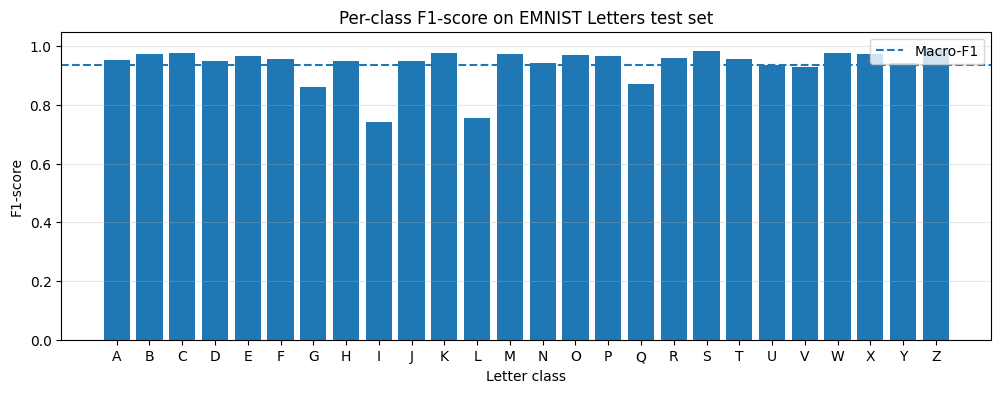

In [88]:
# ============================================================
# Per-class F1-score visualization
# ============================================================

plt.figure(figsize=(12, 4))

plt.bar(
    emnist_per_class_metrics["class"],
    emnist_per_class_metrics["f1-score"]
)

plt.axhline(
    emnist_global_metrics.loc[0, "macro_f1"],
    linestyle="--",
    label="Macro-F1"
)

plt.xlabel("Letter class")
plt.ylabel("F1-score")
plt.title("Per-class F1-score on EMNIST Letters test set")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

The per-class F1 plot confirms that the model performs consistently well for most letters, with many classes above the macro-F1 average. The main weaknesses are the letters I and L, followed by G and Q. These lower-scoring classes are likely affected by handwriting ambiguity and visual similarity between letter shapes. This motivates the next error-analysis step using a normalized confusion matrix and top confused class pairs.

## Training dynamics and model-selection behavior

The model-selection phase is inspected by plotting the training and validation curves for each CNN configuration. These curves help evaluate convergence behavior and whether the models show signs of overfitting or underfitting. The final architecture was selected using validation performance, not test performance.

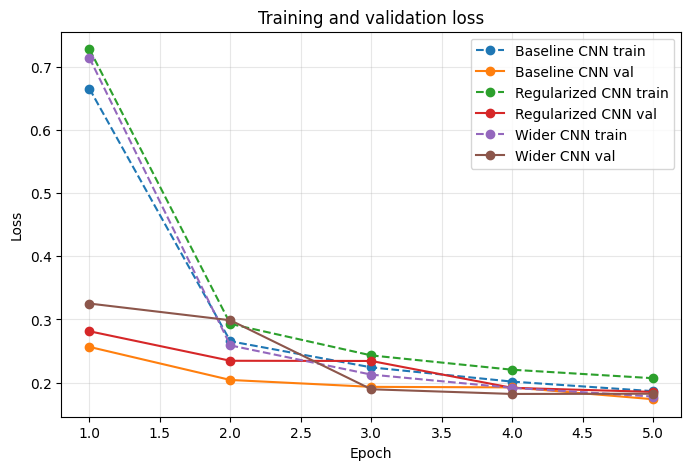

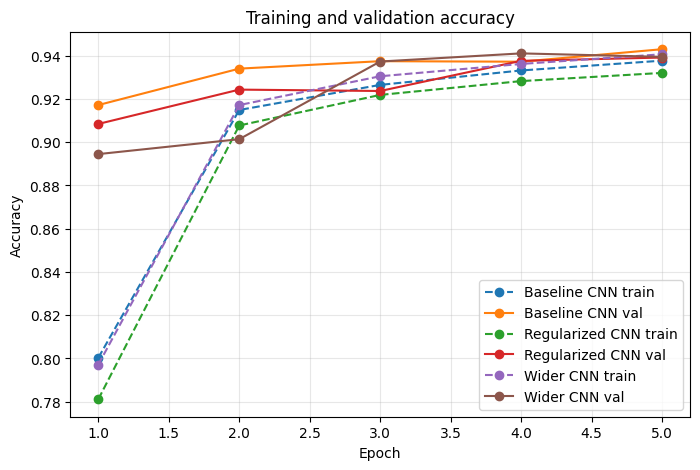

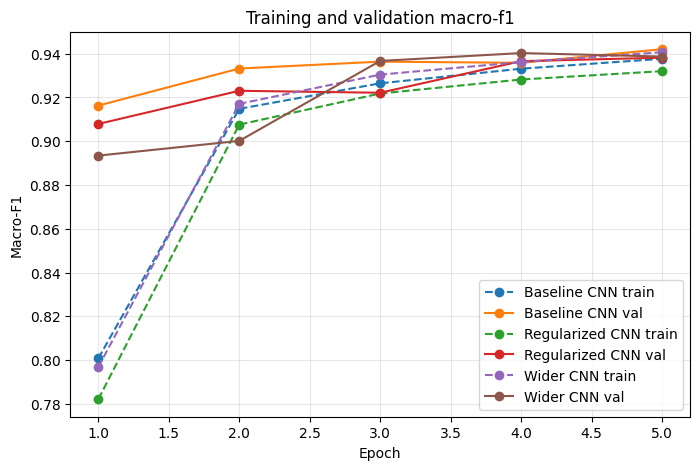

In [89]:
# ============================================================
# Training dynamics plots
# ============================================================

def plot_training_dynamics(history_df):
    metrics = [
        ("train_loss", "val_loss", "Loss"),
        ("train_accuracy", "val_accuracy", "Accuracy"),
        ("train_f1", "val_f1", "Macro-F1")
    ]
    
    for train_metric, val_metric, title in metrics:
        plt.figure(figsize=(8, 5))
        
        for model_name in history_df["model"].unique():
            model_history = history_df[history_df["model"] == model_name]
            
            plt.plot(
                model_history["epoch"],
                model_history[train_metric],
                marker="o",
                linestyle="--",
                label=f"{model_name} train"
            )
            
            plt.plot(
                model_history["epoch"],
                model_history[val_metric],
                marker="o",
                label=f"{model_name} val"
            )
        
        plt.xlabel("Epoch")
        plt.ylabel(title)
        plt.title(f"Training and validation {title.lower()}")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.show()


plot_training_dynamics(emnist_tuning_history)

The training dynamics show stable convergence for all three CNN configurations. Training and validation losses decrease over the five epochs, while accuracy and macro-F1 increase and remain close to each other, suggesting that none of the models suffers from severe overfitting.

When comparing the best validation epoch of each configuration, the Baseline CNN achieves the highest validation performance. The Wider CNN performs similarly, but its larger representational capacity does not provide a clear improvement. The Regularized CNN performs slightly worse, suggesting that stronger dropout and weight decay are not beneficial in this setting.

Therefore, the Baseline CNN is selected as the final EMNIST model for the subsequent representational and robustness analyses.

## Confusion matrix and structured error analysis

The confusion matrix is used to analyze which letter classes are confused by the selected model. This is important because model errors in visual concept learning are often structured: visually similar categories may be confused more often than visually distinct categories.

A normalized confusion matrix is used so that each row represents the distribution of predictions for one true class. This makes it easier to compare error patterns across classes.

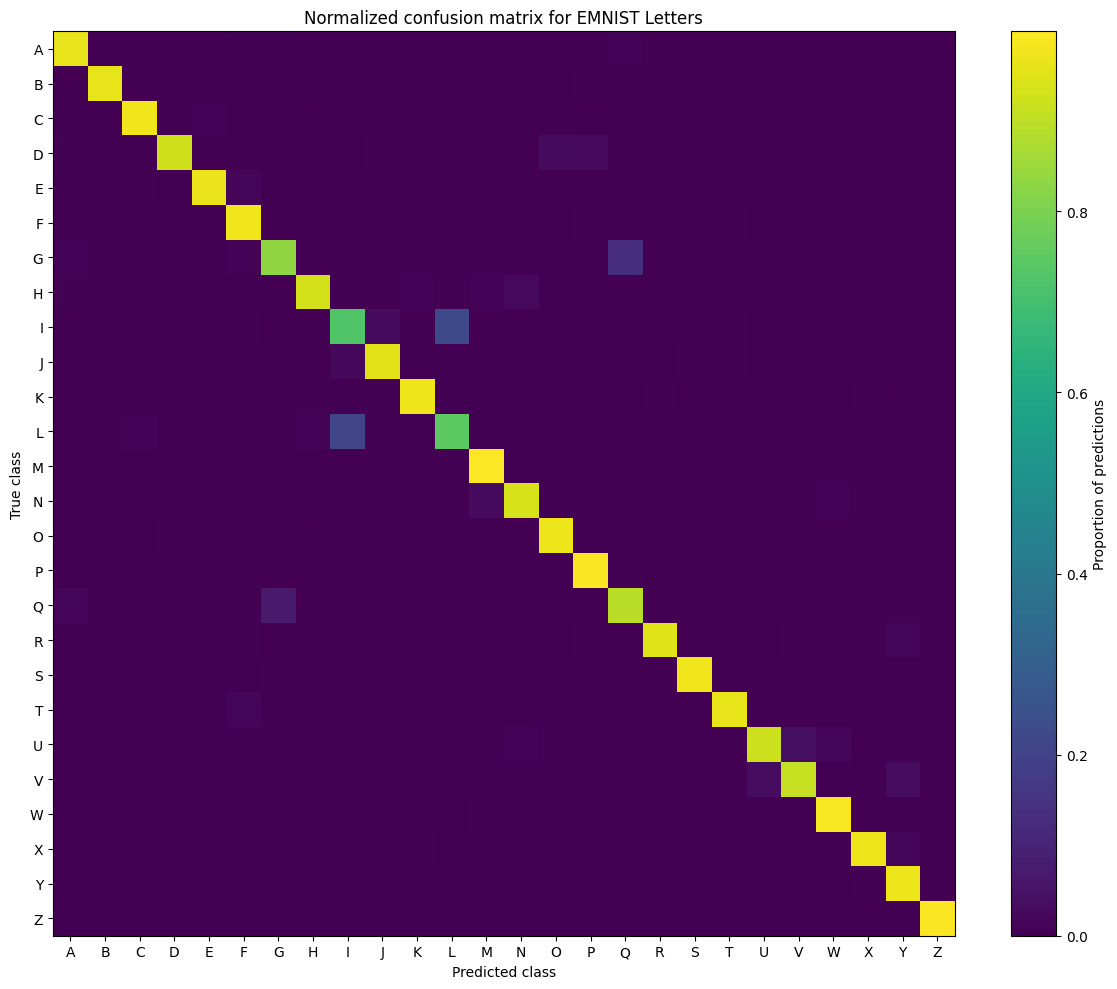

In [90]:
# ============================================================
# Normalized confusion matrix
# ============================================================

from sklearn.metrics import confusion_matrix

emnist_cm = confusion_matrix(
    emnist_y_true,
    emnist_y_pred,
    labels=np.arange(26)
)

emnist_cm_normalized = emnist_cm.astype(float) / emnist_cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(12, 10))

plt.imshow(emnist_cm_normalized, interpolation="nearest", aspect="auto")
plt.colorbar(label="Proportion of predictions")

plt.xticks(np.arange(26), emnist_classes)
plt.yticks(np.arange(26), emnist_classes)

plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Normalized confusion matrix for EMNIST Letters")

plt.tight_layout()
plt.show()

The normalized confusion matrix shows a strong diagonal structure, confirming that most test examples are classified correctly. The visible off-diagonal regions indicate that errors are not uniformly random, but concentrated around specific letter pairs. This suggests that some mistakes are related to visual similarity or ambiguity in handwritten letter shapes.

In [91]:
# ============================================================
# Top confused class pairs
# ============================================================

confusion_pairs = []

for true_idx in range(26):
    for pred_idx in range(26):
        if true_idx != pred_idx:
            confusion_pairs.append({
                "true_class": emnist_classes[true_idx],
                "predicted_class": emnist_classes[pred_idx],
                "count": emnist_cm[true_idx, pred_idx],
                "proportion_within_true_class": emnist_cm_normalized[true_idx, pred_idx]
            })

top_confusions = (
    pd.DataFrame(confusion_pairs)
    .sort_values("count", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

top_confusions

,true_class,predicted_class,count,proportion_within_true_class
0,I,L,177,0.22125
1,L,I,167,0.20875
2,G,Q,104,0.13000
3,Q,G,58,0.07250
4,U,V,29,0.03625
5,V,Y,28,0.03500
6,V,U,28,0.03500
7,N,M,24,0.03000
8,D,O,23,0.02875
9,I,J,22,0.02750


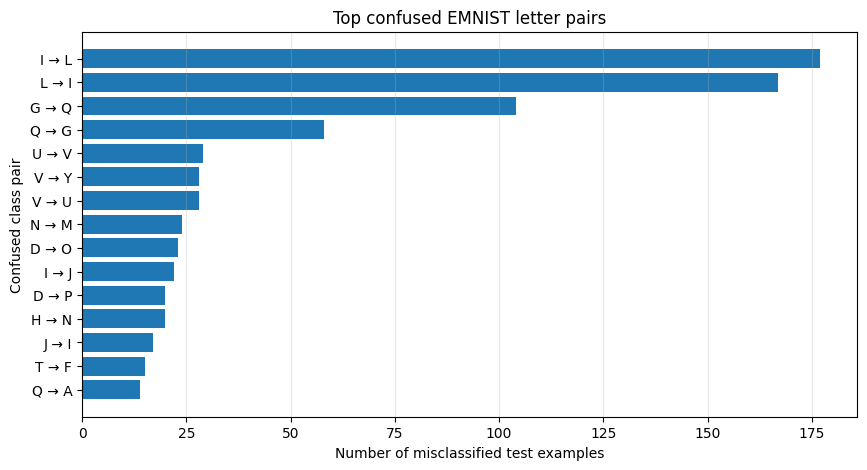

In [92]:
# ============================================================
# Visualize top confused class pairs
# ============================================================

top_confusions_plot = top_confusions.copy()
top_confusions_plot["pair"] = (
    top_confusions_plot["true_class"] 
    + " → " 
    + top_confusions_plot["predicted_class"]
)

plt.figure(figsize=(10, 5))

plt.barh(
    top_confusions_plot["pair"][::-1],
    top_confusions_plot["count"][::-1]
)

plt.xlabel("Number of misclassified test examples")
plt.ylabel("Confused class pair")
plt.title("Top confused EMNIST letter pairs")
plt.grid(axis="x", alpha=0.3)
plt.show()

The top-confusion plot makes the error structure explicit. The dominant errors are I → L and L → I, which account for far more mistakes than any other pair. This is consistent with the low per-class F1 scores previously observed for I and L. The next strongest confusion is G → Q / Q → G, another visually similar pair in handwritten form. Overall, the model's errors appear concentrated around perceptually ambiguous letter pairs rather than being uniformly distributed across all classes.

## Layer-wise linear read-outs

To test whether visual representations become increasingly disentangled across the CNN hierarchy, linear classifiers are trained on representations extracted from different levels of the selected model.

The logic is the following: if a representation is more disentangled, then a simple linear classifier should be able to separate the letter classes more easily. Therefore, linear read-out performance is used as a quantitative measure of class separability at different levels of the model hierarchy.

Representations are extracted from:

1. raw input pixels;
2. convolutional block 1;
3. convolutional block 2;
4. convolutional block 3.

In [93]:
# ============================================================
# Feature extraction for layer-wise linear read-outs
# ============================================================

def extract_features_for_readout(model, dataloader, device, max_batches=None):
    """
    Extract raw-pixel features and pooled intermediate CNN features.

    Convolutional feature maps are globally averaged over spatial
    dimensions. This gives one compact feature vector per image and
    makes the linear read-out analysis faster and more interpretable.
    """
    model.eval()
    
    feature_storage = {
        "pixels": [],
        "block1": [],
        "block2": [],
        "block3": []
    }
    
    label_storage = []
    
    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(dataloader):
            images = images.to(device)
            
            logits, features = model(images, return_features=True)
            
            pixel_features = images.view(images.size(0), -1)
            
            block1_features = features["block1"].mean(dim=(2, 3))
            block2_features = features["block2"].mean(dim=(2, 3))
            block3_features = features["block3"].view(images.size(0), -1)
            
            feature_storage["pixels"].append(pixel_features.cpu().numpy())
            feature_storage["block1"].append(block1_features.cpu().numpy())
            feature_storage["block2"].append(block2_features.cpu().numpy())
            feature_storage["block3"].append(block3_features.cpu().numpy())
            
            label_storage.append(labels.numpy())
            
            if max_batches is not None and batch_idx + 1 >= max_batches:
                break
    
    extracted_features = {
        layer_name: np.concatenate(layer_features, axis=0)
        for layer_name, layer_features in feature_storage.items()
    }
    
    extracted_labels = np.concatenate(label_storage, axis=0)
    
    return extracted_features, extracted_labels


print("Pooled feature extraction function defined.")

Pooled feature extraction function defined.


### Extracting pooled features for linear read-outs

The selected EMNIST model is used to extract representations from different hierarchy levels. For convolutional blocks, global average pooling is applied so that each image is represented by one compact feature vector per layer. This makes the read-out analysis efficient and focuses on channel-level representations rather than raw spatial activations.

In [94]:
# ============================================================
# Extract EMNIST features for linear read-outs
# ============================================================

READOUT_TRAIN_BATCHES = 120   # 120 × 128 = 15,360 training examples
READOUT_TEST_BATCHES = None   # use the full EMNIST test set

emnist_train_features, emnist_train_labels = extract_features_for_readout(
    model=best_emnist_model,
    dataloader=emnist_loaders["train"],
    device=DEVICE,
    max_batches=READOUT_TRAIN_BATCHES
)

emnist_test_features, emnist_test_labels = extract_features_for_readout(
    model=best_emnist_model,
    dataloader=emnist_loaders["test"],
    device=DEVICE,
    max_batches=READOUT_TEST_BATCHES
)

for layer_name in emnist_train_features:
    print(
        layer_name,
        "train shape:", emnist_train_features[layer_name].shape,
        "| test shape:", emnist_test_features[layer_name].shape
    )

print("Train labels shape:", emnist_train_labels.shape)
print("Test labels shape:", emnist_test_labels.shape)
print("Unique test labels:", len(np.unique(emnist_test_labels)))

pixels train shape: (15360, 784) | test shape: (20800, 784)
block1 train shape: (15360, 32) | test shape: (20800, 32)
block2 train shape: (15360, 64) | test shape: (20800, 64)
block3 train shape: (15360, 128) | test shape: (20800, 128)
Train labels shape: (15360,)
Test labels shape: (20800,)
Unique test labels: 26


The extracted representations become more compact after pooling. Raw pixels have 784 dimensions, while block 1, block 2, and block 3 produce 32-, 64-, and 128-dimensional feature vectors respectively. These representations will be evaluated using the same linear classifier, allowing a fair comparison of linear separability across the model hierarchy.

### Training linear read-outs

A separate linear classifier is trained on each representation level. Since the classifier is linear, differences in read-out performance reflect how linearly separable the letter categories are at each level of the model hierarchy.

In [95]:
# ============================================================
# Train linear read-outs on each representation
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

readout_results = []

for layer_name in ["pixels", "block1", "block2", "block3"]:
    print(f"Training linear read-out on: {layer_name}")
    
    linear_readout = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=500,
            solver="lbfgs",
            n_jobs=-1,
            random_state=SEED
        )
    )
    
    linear_readout.fit(
        emnist_train_features[layer_name],
        emnist_train_labels
    )
    
    predictions = linear_readout.predict(
        emnist_test_features[layer_name]
    )
    
    readout_results.append({
        "representation": layer_name,
        "accuracy": accuracy_score(emnist_test_labels, predictions),
        "macro_f1": f1_score(
            emnist_test_labels,
            predictions,
            average="macro",
            labels=np.arange(26),
            zero_division=0
        )
    })

emnist_readout_results = pd.DataFrame(readout_results)
emnist_readout_results

Training linear read-out on: pixels
Training linear read-out on: block1
Training linear read-out on: block2
Training linear read-out on: block3


,representation,accuracy,macro_f1
0,pixels,0.611058,0.610362
1,block1,0.684952,0.682542
2,block2,0.929327,0.929182
3,block3,0.940385,0.940362


The layer-wise linear read-out results show a clear increase in class separability across the CNN hierarchy. A linear classifier trained directly on raw pixels reaches only moderate performance, while read-outs from block 1 improve slightly. A large improvement appears at block 2, and the highest performance is obtained from block 3. This supports the hypothesis that deeper layers transform the input into increasingly disentangled visual concept representations.

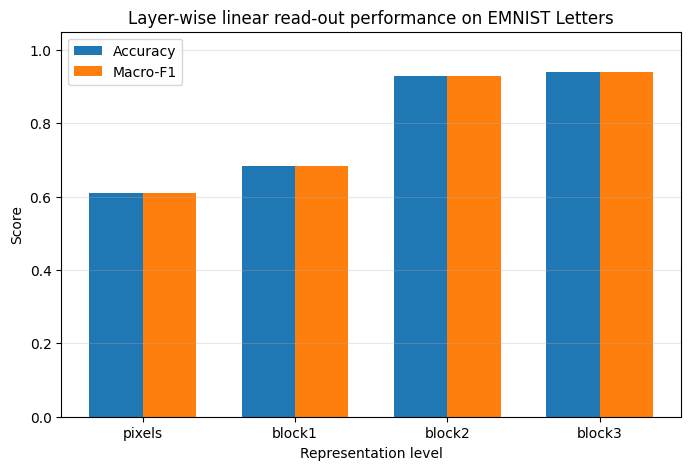

In [96]:
# ============================================================
# Visualize layer-wise linear read-out performance
# ============================================================

plt.figure(figsize=(8, 5))

x = np.arange(len(emnist_readout_results))
width = 0.35

plt.bar(
    x - width / 2,
    emnist_readout_results["accuracy"],
    width,
    label="Accuracy"
)

plt.bar(
    x + width / 2,
    emnist_readout_results["macro_f1"],
    width,
    label="Macro-F1"
)

plt.xticks(x, emnist_readout_results["representation"])
plt.ylim(0, 1.05)
plt.xlabel("Representation level")
plt.ylabel("Score")
plt.title("Layer-wise linear read-out performance on EMNIST Letters")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

### Interpretation of the linear read-out results

The linear read-out analysis tests whether the representations produced at different levels of the CNN become more linearly separable. A linear classifier has limited flexibility, so high linear read-out accuracy indicates that the representation already separates the classes in a useful way.

The results show a clear improvement from raw pixels to deeper convolutional layers. This suggests that the CNN progressively transforms the original sensory input into a more abstract and disentangled feature space. In the raw pixel space, visually similar letters share many local strokes and are harder to separate. In deeper layers, the network combines local visual features into higher-level patterns that are more directly useful for category recognition.

This supports the idea that hierarchical visual models can gradually transform low-level sensory representations into more abstract concept representations.

## Internal representation geometry

The previous analysis showed that deeper CNN layers provide more linearly separable representations. The next step is to analyze the geometry of these internal representations.

For this analysis, the high-level representation from block 3 is used. Each test image is represented by a 128-dimensional feature vector. Class centroids are computed by averaging the block 3 representations for each letter class. These centroids are then used to study similarity relationships between visual concepts.

In [97]:
# ============================================================
# Class centroids from block 3 representations
# ============================================================

block3_test_features = emnist_test_features["block3"]

class_centroids = []

for class_idx in range(26):
    class_features = block3_test_features[emnist_test_labels == class_idx]
    centroid = class_features.mean(axis=0)
    class_centroids.append(centroid)

class_centroids = np.vstack(class_centroids)

print("Block 3 test features shape:", block3_test_features.shape)
print("Class centroids shape:", class_centroids.shape)

Block 3 test features shape: (20800, 128)
Class centroids shape: (26, 128)


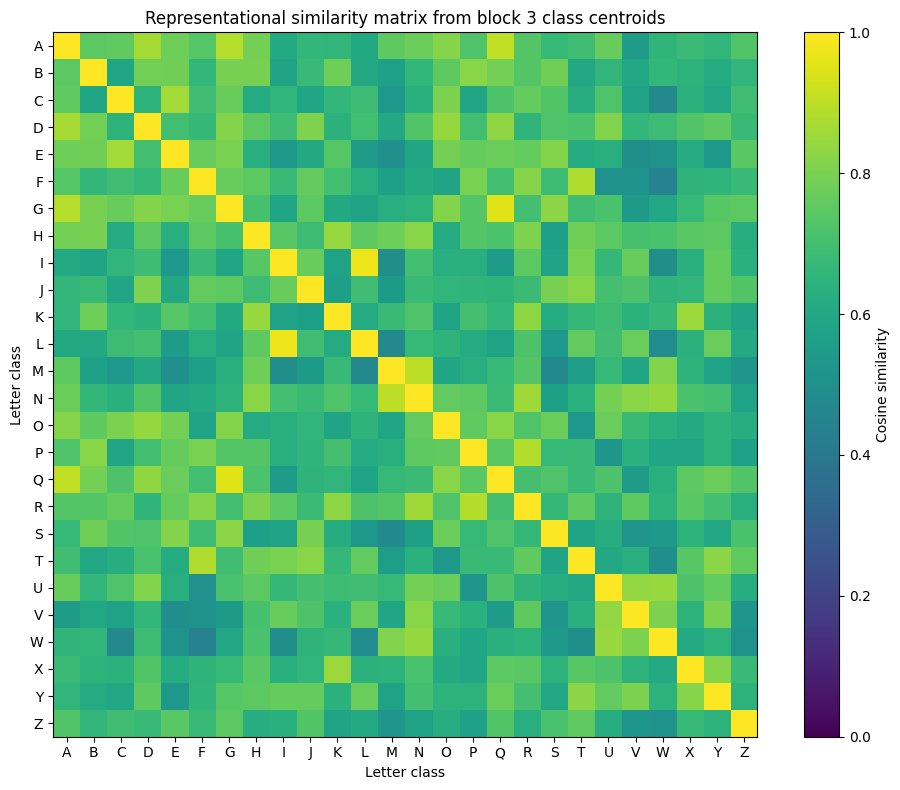

In [98]:
# ============================================================
# Representational similarity matrix
# ============================================================

from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(class_centroids)

plt.figure(figsize=(10, 8))
plt.imshow(similarity_matrix, interpolation="nearest", vmin=0, vmax=1)
plt.colorbar(label="Cosine similarity")

plt.xticks(np.arange(26), emnist_classes)
plt.yticks(np.arange(26), emnist_classes)

plt.xlabel("Letter class")
plt.ylabel("Letter class")
plt.title("Representational similarity matrix from block 3 class centroids")

plt.tight_layout()
plt.show()

The representational similarity matrix shows how close the learned block 3 class centroids are to each other. The diagonal corresponds to self-similarity and is therefore maximal. Off-diagonal similarities indicate relationships between different letter concepts in the model's internal representation space. Higher similarity between two classes suggests that the model represents those letters as more visually or conceptually related.

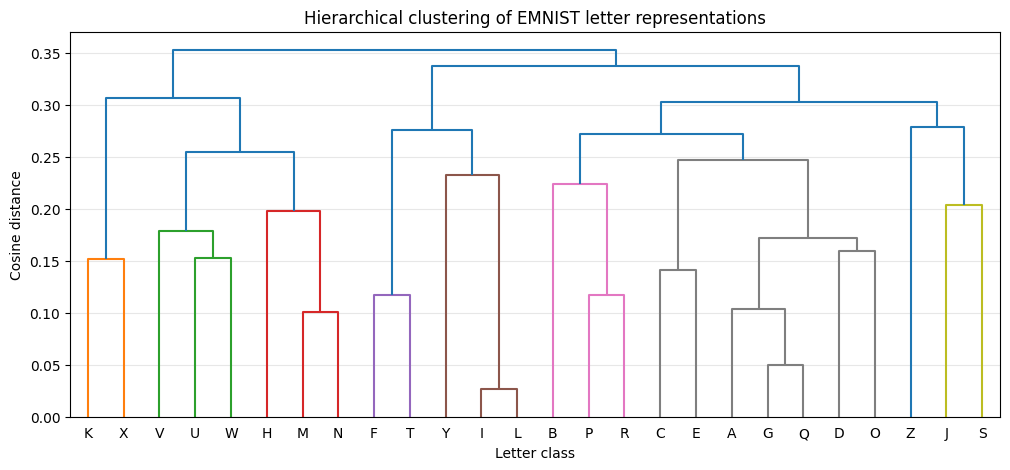

In [99]:
# ============================================================
# Hierarchical clustering of class centroids
# ============================================================

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist

# Cosine distance = 1 - cosine similarity
centroid_distances = pdist(class_centroids, metric="cosine")

linkage_matrix = linkage(
    centroid_distances,
    method="average"
)

plt.figure(figsize=(12, 5))

dendrogram(
    linkage_matrix,
    labels=emnist_classes,
    leaf_rotation=0,
    leaf_font_size=10
)

plt.title("Hierarchical clustering of EMNIST letter representations")
plt.xlabel("Letter class")
plt.ylabel("Cosine distance")
plt.grid(axis="y", alpha=0.3)
plt.show()

The hierarchical clustering dendrogram reveals groups of letters that are close in the model's internal representation space. Several clusters correspond to visually similar handwritten forms, such as I–L, G–Q, U–V/W, and M–N. Importantly, some of these clusters are consistent with the confusion-matrix analysis, where I/L and G/Q were among the most frequent errors. This suggests that the model's classification mistakes are related to the geometry of its learned visual concept representations.

In [100]:
# ============================================================
# Silhouette score of block 3 representations
# ============================================================

from sklearn.metrics import silhouette_score

# Use a subset for efficiency
SILHOUETTE_SAMPLES = 5000

rng = np.random.default_rng(SEED)
subset_indices = rng.choice(
    len(block3_test_features),
    size=min(SILHOUETTE_SAMPLES, len(block3_test_features)),
    replace=False
)

block3_subset = block3_test_features[subset_indices]
labels_subset = emnist_test_labels[subset_indices]

block3_silhouette = silhouette_score(
    block3_subset,
    labels_subset,
    metric="cosine"
)

print(f"Block 3 silhouette score: {block3_silhouette:.4f}")

Block 3 silhouette score: 0.4232


The block 3 representations obtain a silhouette score of 0.4232 using cosine distance. This indicates a moderate degree of class separation in the learned representation space. The score is not close to 1, which is expected for handwritten letters because several classes have overlapping visual forms. This result is consistent with the confusion and clustering analyses: the model develops structured concept representations, but visually similar letters such as I/L and G/Q remain partially overlapping.

## Feature visualization

To complement the representation-geometry analysis, the first convolutional filters of the selected CNN are visualized. These filters are closest to the input image and can reveal whether the model has learned local stroke-like, edge-like, or contrast-sensitive patterns that are useful for handwritten letter recognition.

First convolutional layer weight shape: torch.Size([32, 1, 3, 3])


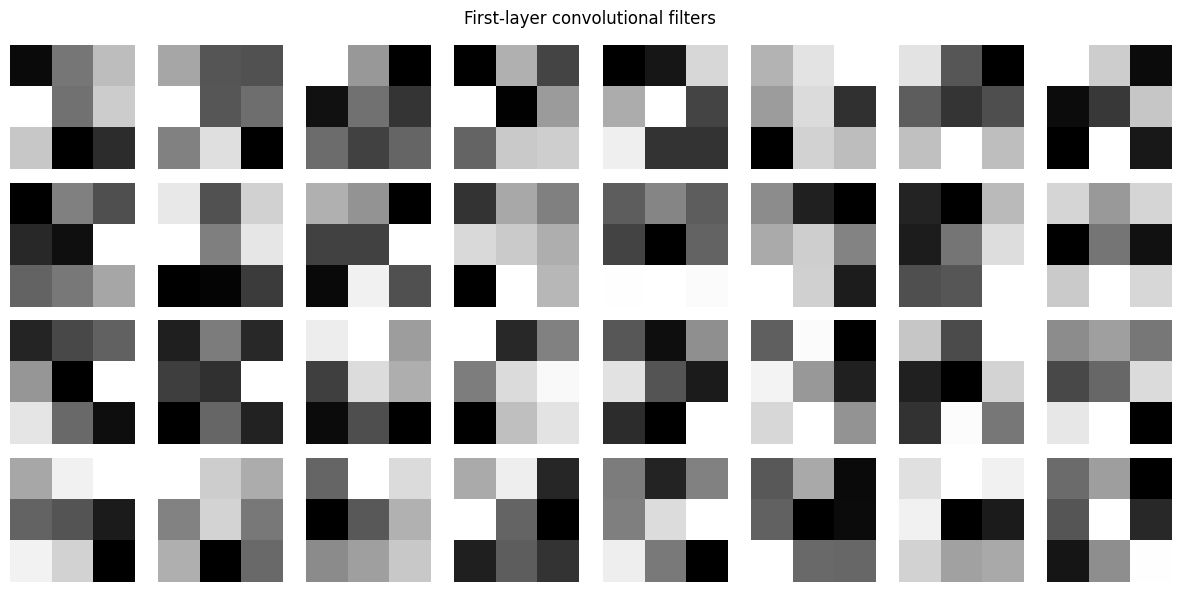

In [101]:
# ============================================================
# Visualize first-layer convolutional filters
# ============================================================

first_conv_layer = best_emnist_model.conv_block1[0]
filters = first_conv_layer.weight.detach().cpu()

print("First convolutional layer weight shape:", filters.shape)

n_filters = filters.shape[0]
n_cols = 8
n_rows = int(np.ceil(n_filters / n_cols))

plt.figure(figsize=(12, 6))

for i in range(n_filters):
    filter_image = filters[i, 0].numpy()
    
    plt.subplot(n_rows, n_cols, i + 1)
    plt.imshow(filter_image, cmap="gray")
    plt.axis("off")

plt.suptitle("First-layer convolutional filters")
plt.tight_layout()
plt.show()

The first-layer filters are small 3 × 3 kernels, so they do not represent complete letters. Instead, they encode local contrast patterns that can detect simple stroke fragments, edges, and small changes in intensity. These low-level visual features form the basis for the more abstract representations learned in deeper convolutional blocks.

### Activation maps for a test image

In addition to visualizing the learned filters, activation maps are shown for one correctly classified test image. These maps illustrate how different convolutional channels respond to local parts of the input letter.

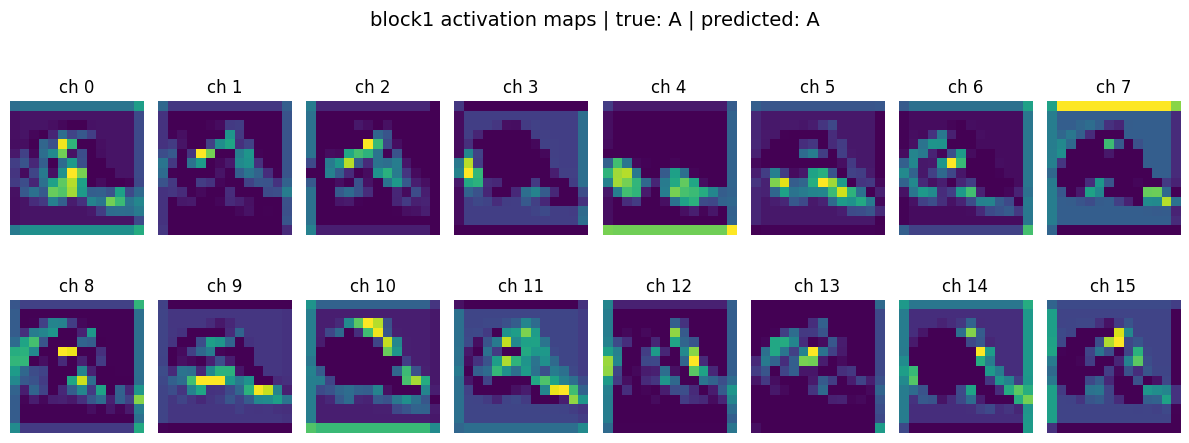

In [102]:
# ============================================================
# Visualize activation maps for one test image
# ============================================================

def visualize_activation_maps(model, dataset, class_names, index=0, layer_name="block1", n_maps=16):
    model.eval()
    
    image, label = dataset[index]
    image_batch = image.unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        logits, features = model(image_batch, return_features=True)
        prediction = torch.argmax(logits, dim=1).item()
    
    activation = features[layer_name].squeeze(0).cpu()
    
    n_maps = min(n_maps, activation.shape[0])
    n_cols = 8
    n_rows = int(np.ceil(n_maps / n_cols))
    
    plt.figure(figsize=(12, 2.5 * n_rows))
    
    for i in range(n_maps):
        plt.subplot(n_rows, n_cols, i + 1)
        plt.imshow(activation[i].numpy(), cmap="viridis")
        plt.axis("off")
        plt.title(f"ch {i}")
    
    plt.suptitle(
        f"{layer_name} activation maps | true: {class_names[label]} | predicted: {class_names[prediction]}",
        fontsize=14
    )
    plt.tight_layout()
    plt.show()


visualize_activation_maps(
    model=best_emnist_model,
    dataset=emnist_test,
    class_names=emnist_classes,
    index=0,
    layer_name="block1",
    n_maps=16
)

### Comparing activation maps across hierarchical levels

To better analyze how the CNN builds hierarchical representations, I visualize activation maps from early, intermediate, and deep convolutional blocks for the same input image. This allows us to compare how the representation changes from local stroke-like features to more abstract and spatially compressed responses.

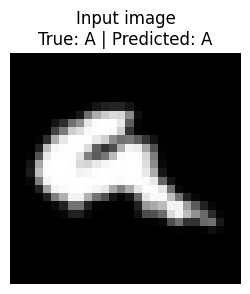

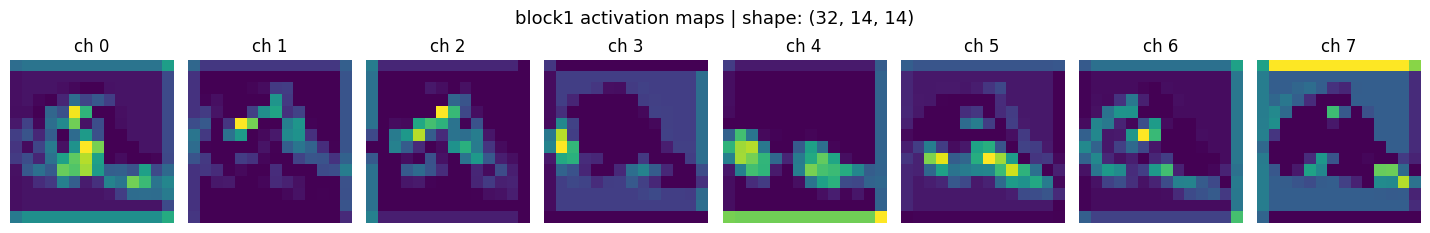

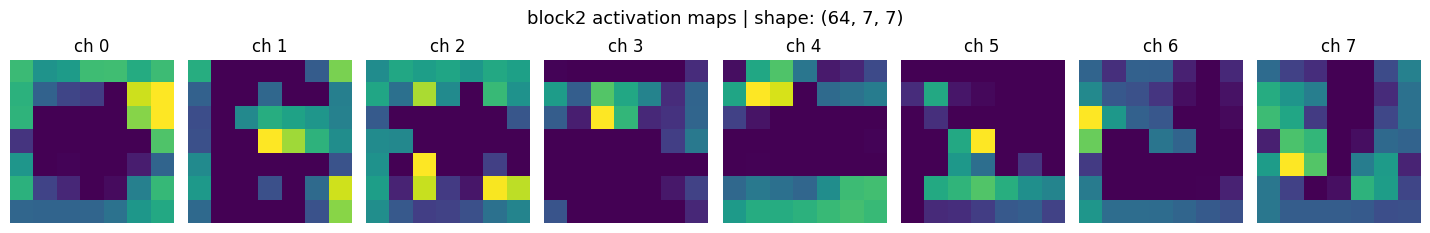

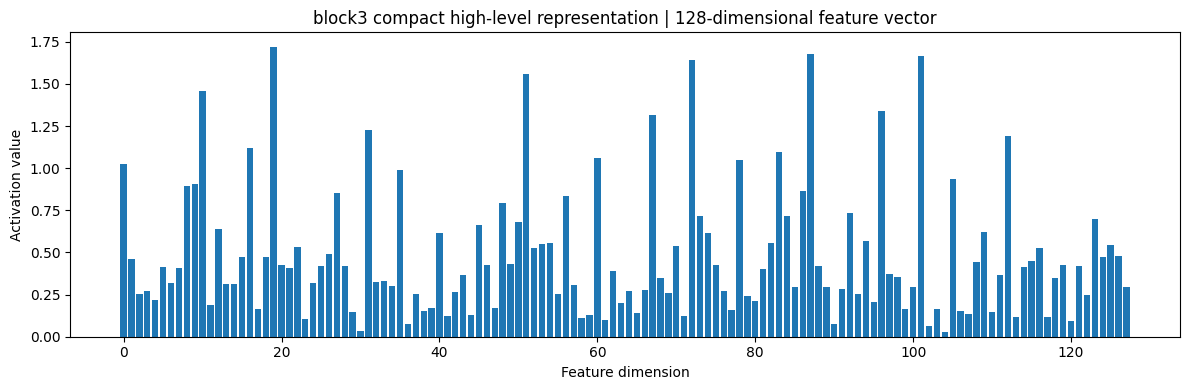

In [103]:
# ============================================================
# Hierarchical activation maps across CNN blocks
# ============================================================

def visualize_hierarchical_activation_maps(
    model,
    dataset,
    class_names,
    index=0,
    n_maps=8
):
    """
    Visualize activation maps from block1 and block2, and visualize
    the compact block3 representation as a feature-vector bar plot.
    """
    model.eval()

    image, label = dataset[index]
    image_batch = image.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits, features = model(image_batch, return_features=True)
        prediction = torch.argmax(logits, dim=1).item()

    # Show original input image
    plt.figure(figsize=(3, 3))
    plt.imshow(image.squeeze().cpu().numpy(), cmap="gray")
    plt.title(
        f"Input image\nTrue: {class_names[label]} | Predicted: {class_names[prediction]}"
    )
    plt.axis("off")
    plt.show()

    # Show activation maps from block1 and block2
    for layer_name in ["block1", "block2"]:
        activation = features[layer_name].squeeze(0).detach().cpu()
        maps_to_show = min(n_maps, activation.shape[0])

        plt.figure(figsize=(1.8 * maps_to_show, 2.4))

        for i in range(maps_to_show):
            plt.subplot(1, maps_to_show, i + 1)
            plt.imshow(activation[i].numpy(), cmap="viridis")
            plt.axis("off")
            plt.title(f"ch {i}")

        plt.suptitle(
            f"{layer_name} activation maps | shape: {tuple(activation.shape)}",
            fontsize=13
        )
        plt.tight_layout()
        plt.show()

    # Show block3 as a compact high-level feature vector
    block3_vector = features["block3"].squeeze().detach().cpu().numpy()

    plt.figure(figsize=(12, 4))
    plt.bar(range(len(block3_vector)), block3_vector)
    plt.title("block3 compact high-level representation | 128-dimensional feature vector")
    plt.xlabel("Feature dimension")
    plt.ylabel("Activation value")
    plt.tight_layout()
    plt.show()


visualize_hierarchical_activation_maps(
    model=best_emnist_model,
    dataset=emnist_test,
    class_names=emnist_classes,
    index=0,
    n_maps=8
)

### Interpretation of hierarchical activation maps

The visualization shows a clear change across the CNN hierarchy. In block1, the activation maps preserve relatively detailed spatial information and respond to local stroke-like patterns. In block2, the representation becomes more spatially compressed and combines local visual features into more structured patterns.

In block3, the spatial structure has been reduced to a compact 128-dimensional high-level feature vector. Therefore, block3 is not best interpreted as an image-like activation map, but as an abstract representation that summarizes the category-relevant information extracted from the input.

This supports the layer-wise linear read-out results. Deeper layers are not simply preserving the raw image; they reorganize the input into a feature space where class information becomes easier to separate.

The activation maps show that different block 1 channels respond to different local parts of the input letter. Some channels emphasize stroke regions, while others respond to boundaries or local contrast patterns. This supports the interpretation that early convolutional layers encode local sensory features, which are progressively combined into more abstract representations in deeper layers.

## Psychometric robustness curves

Psychometric curves are used to study how recognition performance changes as sensory uncertainty increases. In this experiment, increasing levels of Gaussian noise are added to the EMNIST test images, and the selected model is evaluated at each noise level.

The resulting curve shows how robust the learned visual concepts are when the input becomes progressively noisier.

In [104]:
# ============================================================
# Evaluation under Gaussian noise
# ============================================================

def evaluate_with_gaussian_noise(model, dataloader, noise_std, device, num_classes):
    """
    Evaluate a trained model after adding Gaussian noise to input images.
    Inputs are normalized in approximately [-1, 1], so noisy images are
    clipped back to this range.
    """
    model.eval()
    
    all_labels = []
    all_predictions = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            
            noise = torch.randn_like(images) * noise_std
            noisy_images = images + noise
            noisy_images = torch.clamp(noisy_images, -1.0, 1.0)
            
            logits = model(noisy_images)
            predictions = torch.argmax(logits, dim=1)
            
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())
    
    accuracy = accuracy_score(all_labels, all_predictions)
    macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        labels=np.arange(num_classes),
        zero_division=0
    )
    
    return accuracy, macro_f1


noise_levels = [0.00, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40]

noise_results = []

for noise_std in noise_levels:
    accuracy, macro_f1 = evaluate_with_gaussian_noise(
        model=best_emnist_model,
        dataloader=emnist_loaders["test"],
        noise_std=noise_std,
        device=DEVICE,
        num_classes=26
    )
    
    noise_results.append({
        "noise_std": noise_std,
        "accuracy": accuracy,
        "macro_f1": macro_f1
    })
    
    print(
        f"Noise std: {noise_std:.2f} | "
        f"accuracy: {accuracy:.4f} | "
        f"macro-F1: {macro_f1:.4f}"
    )

emnist_noise_results = pd.DataFrame(noise_results)
emnist_noise_results

Noise std: 0.00 | accuracy: 0.9386 | macro-F1: 0.9382
Noise std: 0.05 | accuracy: 0.9332 | macro-F1: 0.9325
Noise std: 0.10 | accuracy: 0.9052 | macro-F1: 0.9024
Noise std: 0.15 | accuracy: 0.7979 | macro-F1: 0.7768
Noise std: 0.20 | accuracy: 0.6533 | macro-F1: 0.6226
Noise std: 0.30 | accuracy: 0.3406 | macro-F1: 0.2971
Noise std: 0.40 | accuracy: 0.1678 | macro-F1: 0.1295


,noise_std,accuracy,macro_f1
0,0.00,0.938558,0.938239
1,0.05,0.933173,0.932549
2,0.10,0.905240,0.902362
3,0.15,0.797885,0.776761
4,0.20,0.653317,0.622645
5,0.30,0.340577,0.297092
6,0.40,0.167788,0.129505


The psychometric evaluation shows a clear degradation of recognition performance as Gaussian noise increases. Performance remains high at low noise levels, but drops sharply after a noise standard deviation of approximately 0.15. At higher noise levels, the model loses much of its ability to distinguish letter classes. This produces a psychometric-like curve, where recognition accuracy decreases as the sensory signal becomes increasingly corrupted.

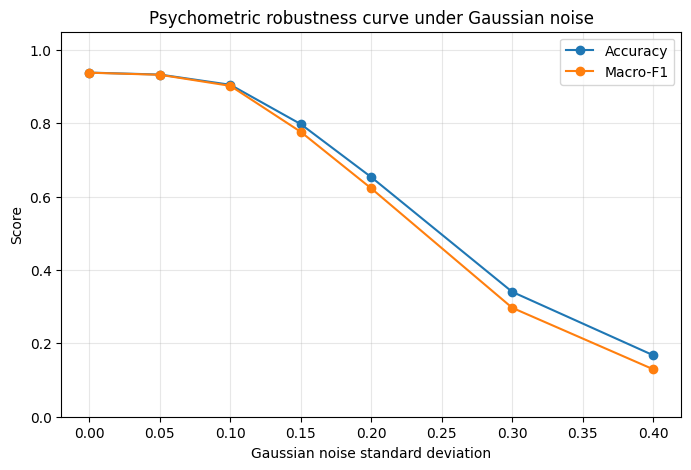

In [105]:
# ============================================================
# Plot psychometric robustness curve
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    emnist_noise_results["noise_std"],
    emnist_noise_results["accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    emnist_noise_results["noise_std"],
    emnist_noise_results["macro_f1"],
    marker="o",
    label="Macro-F1"
)

plt.xlabel("Gaussian noise standard deviation")
plt.ylabel("Score")
plt.title("Psychometric robustness curve under Gaussian noise")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

The psychometric curve confirms that the model is robust to small perturbations but increasingly fails as the input becomes noisier. The similar behavior of accuracy and macro-F1 indicates that performance degradation affects the class set broadly, rather than only a few isolated letters.

## Adversarial robustness analysis

In addition to random sensory noise, the model is evaluated under adversarial perturbations. Unlike Gaussian noise, adversarial perturbations are constructed using the model's gradients and are designed to change the model's prediction while remaining small in magnitude.

The Fast Gradient Sign Method (FGSM) is used to generate adversarial examples. The model is evaluated across different perturbation strengths to measure how adversarial vulnerability changes as the perturbation size increases.

This analysis focuses on measuring adversarial vulnerability rather than fully optimizing adversarial robustness. A natural extension would be adversarial training, where FGSM examples are included during training to make the decision boundary less sensitive to gradient-based perturbations.

In [106]:
# ============================================================
# FGSM adversarial attack
# ============================================================

def fgsm_attack(images, epsilon, gradients):
    """
    Fast Gradient Sign Method:
    x_adv = x + epsilon * sign(gradient)
    """
    perturbation = epsilon * gradients.sign()
    adversarial_images = images + perturbation
    adversarial_images = torch.clamp(adversarial_images, -1.0, 1.0)
    
    return adversarial_images


def evaluate_fgsm_attack(model, dataloader, epsilon, device):
    model.eval()
    
    criterion = nn.CrossEntropyLoss()
    
    all_labels = []
    all_predictions = []
    
    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)
        
        images.requires_grad = True
        
        logits = model(images)
        loss = criterion(logits, labels)
        
        model.zero_grad()
        loss.backward()
        
        gradients = images.grad.data
        
        adversarial_images = fgsm_attack(
            images=images,
            epsilon=epsilon,
            gradients=gradients
        )
        
        with torch.no_grad():
            adversarial_logits = model(adversarial_images)
            predictions = torch.argmax(adversarial_logits, dim=1)
        
        all_labels.extend(labels.detach().cpu().numpy())
        all_predictions.extend(predictions.detach().cpu().numpy())
    
    accuracy = accuracy_score(all_labels, all_predictions)
    macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        labels=np.arange(26),
        zero_division=0
    )
    
    return accuracy, macro_f1


epsilon_values = [0.00, 0.01, 0.02, 0.05, 0.10, 0.15]

fgsm_results = []

for epsilon in epsilon_values:
    accuracy, macro_f1 = evaluate_fgsm_attack(
        model=best_emnist_model,
        dataloader=emnist_loaders["test"],
        epsilon=epsilon,
        device=DEVICE
    )
    
    fgsm_results.append({
        "epsilon": epsilon,
        "accuracy": accuracy,
        "macro_f1": macro_f1
    })
    
    print(
        f"Epsilon: {epsilon:.2f} | "
        f"accuracy: {accuracy:.4f} | "
        f"macro-F1: {macro_f1:.4f}"
    )

emnist_fgsm_results = pd.DataFrame(fgsm_results)
emnist_fgsm_results

Epsilon: 0.00 | accuracy: 0.9386 | macro-F1: 0.9382
Epsilon: 0.01 | accuracy: 0.9215 | macro-F1: 0.9210
Epsilon: 0.02 | accuracy: 0.9018 | macro-F1: 0.9010
Epsilon: 0.05 | accuracy: 0.8167 | macro-F1: 0.8140
Epsilon: 0.10 | accuracy: 0.5578 | macro-F1: 0.5362
Epsilon: 0.15 | accuracy: 0.3068 | macro-F1: 0.2746


,epsilon,accuracy,macro_f1
0,0.00,0.938558,0.938239
1,0.01,0.921490,0.921012
2,0.02,0.901779,0.900992
3,0.05,0.816731,0.813985
4,0.10,0.557837,0.536189
5,0.15,0.306779,0.274616


The FGSM results show that adversarial perturbations strongly reduce model performance as epsilon increases. Even though the perturbations are small in magnitude, they are constructed using the model's gradients and therefore target weaknesses in the learned decision boundary. Compared with Gaussian noise, adversarial perturbations produce a sharper drop in performance, showing that the CNN's visual concept representations are useful but not fully robust.

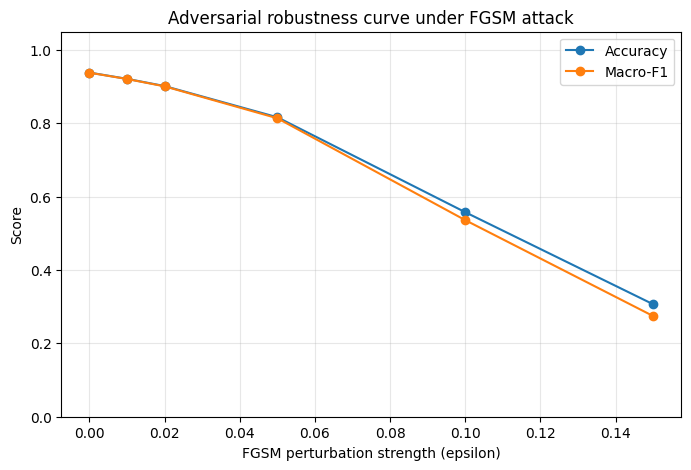

In [107]:
# ============================================================
# Plot adversarial robustness curve
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    emnist_fgsm_results["epsilon"],
    emnist_fgsm_results["accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    emnist_fgsm_results["epsilon"],
    emnist_fgsm_results["macro_f1"],
    marker="o",
    label="Macro-F1"
)

plt.xlabel("FGSM perturbation strength (epsilon)")
plt.ylabel("Score")
plt.title("Adversarial robustness curve under FGSM attack")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

The adversarial robustness curve shows a monotonic decrease in performance as epsilon increases. The decline is sharper than in the low-noise part of the Gaussian psychometric curve, suggesting that adversarial perturbations are more damaging than random sensory corruption of similar magnitude. This highlights a difference between high classification accuracy and robust visual concept learning.

### Visual examples of adversarial perturbations

To qualitatively inspect the FGSM attack, a few original test images are compared with their adversarial versions. The goal is to show how small gradient-based perturbations can change the model's prediction while keeping the input visually similar.

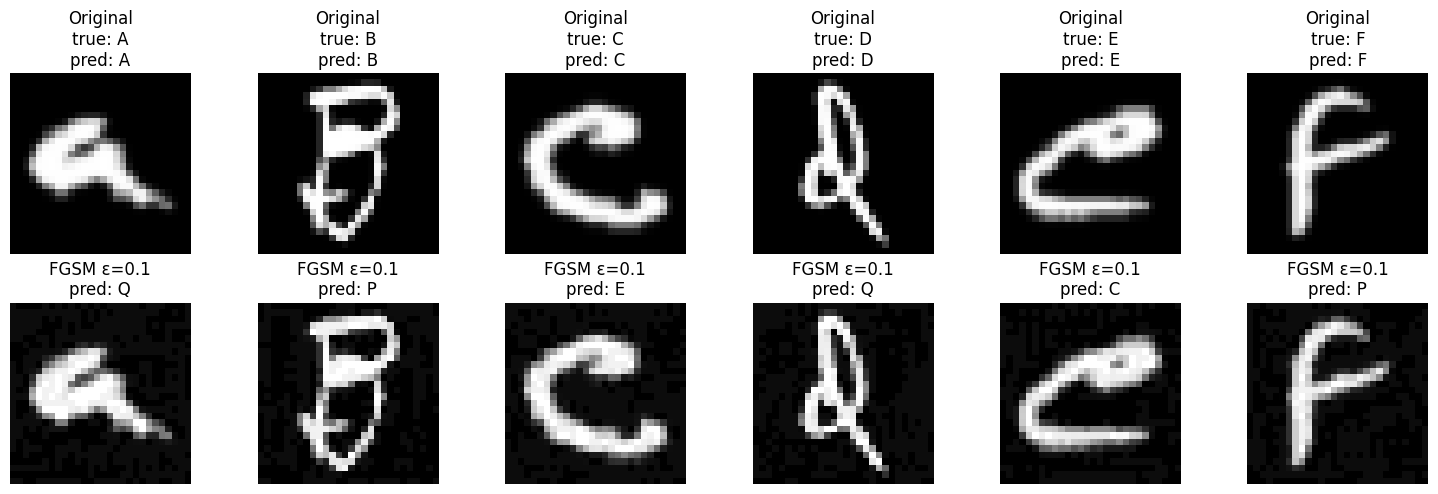

In [108]:
# ============================================================
# Visualize diverse original and adversarial examples
# ============================================================

def visualize_diverse_adversarial_examples(model, dataset, class_names, epsilon=0.10, n_examples=6):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    
    examples = []
    used_true_classes = set()
    
    for idx in range(len(dataset)):
        image, label = dataset[idx]
        
        # Skip if we already have an example from this true class
        if label in used_true_classes:
            continue
        
        image = image.unsqueeze(0).to(DEVICE)
        label_tensor = torch.tensor([label], device=DEVICE)
        
        image.requires_grad = True
        
        logits = model(image)
        original_prediction = torch.argmax(logits, dim=1).item()
        
        loss = criterion(logits, label_tensor)
        model.zero_grad()
        loss.backward()
        
        adversarial_image = fgsm_attack(
            images=image,
            epsilon=epsilon,
            gradients=image.grad.data
        )
        
        with torch.no_grad():
            adversarial_logits = model(adversarial_image)
            adversarial_prediction = torch.argmax(adversarial_logits, dim=1).item()
        
        if original_prediction == label and adversarial_prediction != label:
            examples.append(
                (
                    image.detach().cpu().squeeze().numpy(),
                    adversarial_image.detach().cpu().squeeze().numpy(),
                    label,
                    original_prediction,
                    adversarial_prediction
                )
            )
            used_true_classes.add(label)
        
        if len(examples) >= n_examples:
            break
    
    plt.figure(figsize=(2.5 * len(examples), 5))
    
    for i, (original, adversarial, true_label, original_pred, adv_pred) in enumerate(examples):
        original_display = (original * 0.5) + 0.5
        adversarial_display = (adversarial * 0.5) + 0.5
        
        plt.subplot(2, len(examples), i + 1)
        plt.imshow(original_display, cmap="gray")
        plt.axis("off")
        plt.title(
            f"Original\ntrue: {class_names[true_label]}\npred: {class_names[original_pred]}"
        )
        
        plt.subplot(2, len(examples), i + 1 + len(examples))
        plt.imshow(adversarial_display, cmap="gray")
        plt.axis("off")
        plt.title(
            f"FGSM ε={epsilon}\npred: {class_names[adv_pred]}"
        )
    
    plt.tight_layout()
    plt.show()


visualize_diverse_adversarial_examples(
    model=best_emnist_model,
    dataset=emnist_test,
    class_names=emnist_classes,
    epsilon=0.10,
    n_examples=6
)

The adversarial examples show that small gradient-based perturbations can change the model's prediction even when the images remain visually similar to the original inputs. The examples include multiple true classes, showing that the vulnerability is not limited to a single letter. This demonstrates that high test accuracy does not necessarily imply robust visual perception: the model has learned useful visual representations, but its decision boundaries remain sensitive to carefully constructed perturbations.

### Potential defense: adversarial training

A natural defense against FGSM-like attacks is adversarial training. In adversarial training, the model is exposed not only to clean images, but also to adversarially perturbed images generated during training. This encourages the classifier to learn a smoother and more robust decision boundary.

In this project, I first use FGSM as an analysis tool to test the sensitivity of the learned representation. I then add a compact adversarial fine-tuning experiment as a simple defense demonstration. This is not intended to be a fully optimized robust training procedure, but it allows us to test whether exposure to adversarial examples improves resistance to FGSM perturbations.

This limitation is important from a cognitive perspective. Although CNNs can learn strong hierarchical visual representations, their sensitivity to small adversarial perturbations suggests that their representations do not fully match the robustness of human visual perception.

### Mini defense experiment: adversarial fine-tuning

To test a simple defense, I perform a lightweight adversarial fine-tuning experiment. Starting from the trained EMNIST CNN, the model is fine-tuned using a mixture of clean images and FGSM-perturbed images. The goal is not to fully optimize a robust model, but to test whether exposure to adversarial examples can improve resistance to FGSM perturbations.

The original model and the adversarially fine-tuned model are then compared on clean test images and on FGSM-perturbed test images at different epsilon values.

In [109]:
# ============================================================
# Mini defense experiment: adversarial fine-tuning
# ============================================================

import copy
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt

# Make sure criterion exists
criterion = nn.CrossEntropyLoss()


def fgsm_generate_batch(model, images, labels, epsilon):
    """
    Generate FGSM adversarial examples for one batch.
    The adversarial images are clamped to the same value range as the input batch.
    """
    model.eval()

    images = images.to(DEVICE)
    labels = labels.to(DEVICE)

    images_adv = images.clone().detach()
    images_adv.requires_grad = True

    outputs = model(images_adv)
    loss = criterion(outputs, labels)

    model.zero_grad()
    loss.backward()

    perturbation = epsilon * images_adv.grad.sign()
    adversarial_images = images_adv + perturbation

    # Important: preserve the data range used by the dataset/preprocessing
    min_val = images.min().item()
    max_val = images.max().item()
    adversarial_images = torch.clamp(adversarial_images, min_val, max_val)

    return adversarial_images.detach()


def adversarial_fine_tune(
    base_model,
    train_loader,
    epsilon=0.05,
    max_batches=100,
    lr=1e-4
):
    """
    Fine-tune a copy of the trained model using clean + FGSM images.
    max_batches keeps the experiment lightweight.
    """
    robust_model = copy.deepcopy(base_model).to(DEVICE)
    robust_model.train()

    optimizer = torch.optim.Adam(robust_model.parameters(), lr=lr)

    for batch_idx, (images, labels) in enumerate(train_loader):
        if batch_idx >= max_batches:
            break

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        # Generate adversarial examples using the current model
        adv_images = fgsm_generate_batch(
            robust_model,
            images,
            labels,
            epsilon=epsilon
        )

        # Mix clean and adversarial images
        mixed_images = torch.cat([images, adv_images], dim=0)
        mixed_labels = torch.cat([labels, labels], dim=0)

        robust_model.train()
        optimizer.zero_grad()

        outputs = robust_model(mixed_images)
        loss = criterion(outputs, mixed_labels)

        loss.backward()
        optimizer.step()

    return robust_model


# Fine-tune a robust model using a limited number of batches
adv_finetuned_model = adversarial_fine_tune(
    base_model=best_emnist_model,
    train_loader=emnist_loaders["train"],
    epsilon=0.05,
    max_batches=100,
    lr=1e-4
)

print("Adversarial fine-tuning completed.")

Adversarial fine-tuning completed.


In [110]:
# ============================================================
# Compare original model and adversarially fine-tuned model
# ============================================================

def evaluate_fgsm_accuracy(model, test_loader, epsilons):
    """
    Evaluate clean and FGSM accuracy for a list of epsilon values.
    """
    results = []

    for epsilon in epsilons:
        model.eval()
        correct = 0
        total = 0

        for images, labels in test_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            if epsilon == 0:
                test_images = images
            else:
                test_images = fgsm_generate_batch(
                    model,
                    images,
                    labels,
                    epsilon=epsilon
                )

            with torch.no_grad():
                outputs = model(test_images)
                predictions = torch.argmax(outputs, dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

        accuracy = correct / total
        results.append({
            "epsilon": epsilon,
            "accuracy": accuracy
        })

    return pd.DataFrame(results)


defense_epsilons = [0.00, 0.05, 0.10, 0.15]

original_defense_results = evaluate_fgsm_accuracy(
    best_emnist_model,
    emnist_loaders["test"],
    defense_epsilons
)

adv_finetuned_results = evaluate_fgsm_accuracy(
    adv_finetuned_model,
    emnist_loaders["test"],
    defense_epsilons
)

comparison_defense_results = pd.DataFrame({
    "epsilon": defense_epsilons,
    "original_model_accuracy": original_defense_results["accuracy"],
    "adversarially_finetuned_accuracy": adv_finetuned_results["accuracy"]
})

comparison_defense_results

,epsilon,original_model_accuracy,adversarially_finetuned_accuracy
0,0.00,0.938558,0.945240
1,0.05,0.816731,0.880529
2,0.10,0.557837,0.764375
3,0.15,0.306779,0.538846


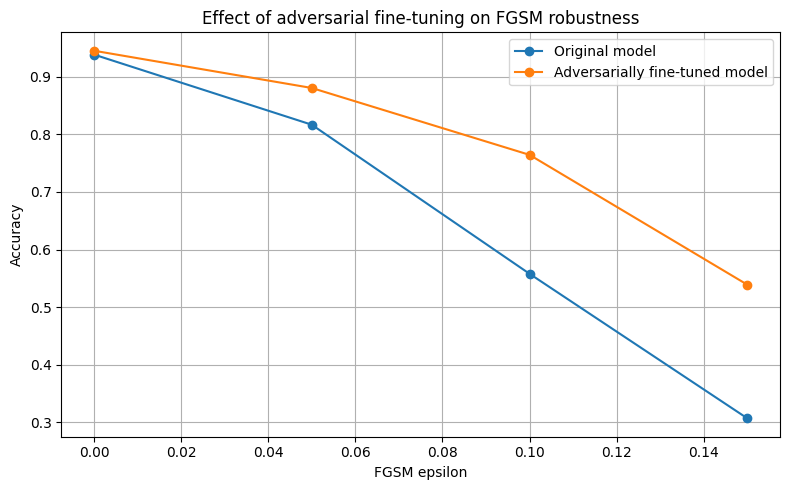

In [111]:
# ============================================================
# Plot defense comparison
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    comparison_defense_results["epsilon"],
    comparison_defense_results["original_model_accuracy"],
    marker="o",
    label="Original model"
)

plt.plot(
    comparison_defense_results["epsilon"],
    comparison_defense_results["adversarially_finetuned_accuracy"],
    marker="o",
    label="Adversarially fine-tuned model"
)

plt.xlabel("FGSM epsilon")
plt.ylabel("Accuracy")
plt.title("Effect of adversarial fine-tuning on FGSM robustness")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Interpretation of the adversarial defense experiment

The adversarial fine-tuning experiment shows that exposure to FGSM-perturbed examples improves robustness against adversarial attacks. The original model has high clean accuracy, but its performance drops substantially as epsilon increases. After adversarial fine-tuning, the model keeps higher accuracy at all non-zero epsilon values.

For example, at epsilon = 0.10, accuracy improves from about 0.56 to about 0.77, and at epsilon = 0.15 it improves from about 0.31 to about 0.55. This suggests that adversarial fine-tuning makes the decision boundary less sensitive to small gradient-based perturbations.

The clean accuracy is also preserved in this experiment. However, this should be interpreted carefully because the fine-tuning was lightweight and limited to a small number of batches. A more complete robustness study would require longer adversarial training, repeated runs, and evaluation against different attack strengths.

From a cognitive-computational perspective, this result is important because it shows that standard CNN representations can be accurate but fragile. Robustness therefore needs to be evaluated separately from ordinary test accuracy.

## Secondary validation on Fashion-MNIST

Fashion-MNIST is used as a secondary visual domain to test whether the analysis is specific to handwritten letters or also applies to object-like visual categories. The same CNN architecture selected on EMNIST is trained on Fashion-MNIST, but the analysis is kept compact to avoid duplicating the full EMNIST pipeline.

The goal is to compare generalization performance and robustness patterns across symbolic visual concepts and object-like visual categories.

In [112]:
# ============================================================
# Train selected CNN architecture on Fashion-MNIST
# ============================================================

fashion_config = {
    "name": "Fashion-MNIST CNN",
    "num_classes": 10,
    "base_filters": 32,
    "dropout": 0.30,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "epochs": 5
}

fashion_model, fashion_history = run_experiment(
    config=fashion_config,
    loaders=fashion_loaders,
    device=DEVICE
)

fashion_history


Training: Fashion-MNIST CNN
Epoch 01 | train acc: 0.7967 | val acc: 0.7672 | val F1: 0.7278
Epoch 02 | train acc: 0.8877 | val acc: 0.8933 | val F1: 0.8937
Epoch 03 | train acc: 0.9050 | val acc: 0.9082 | val F1: 0.9082
Epoch 04 | train acc: 0.9157 | val acc: 0.8948 | val F1: 0.8913
Epoch 05 | train acc: 0.9219 | val acc: 0.8923 | val F1: 0.8909


,model,epoch,train_loss,train_accuracy,train_f1,val_loss,val_accuracy,val_f1
0,Fashion-MNIST CNN,1,0.573078,0.796667,0.794005,0.711967,0.767167,0.727823
1,Fashion-MNIST CNN,2,0.317077,0.887704,0.886847,0.301060,0.893333,0.893695
2,Fashion-MNIST CNN,3,0.269574,0.904963,0.904416,0.258072,0.908167,0.908182
3,Fashion-MNIST CNN,4,0.237835,0.915741,0.915362,0.297086,0.894833,0.891282
4,Fashion-MNIST CNN,5,0.217190,0.921907,0.921585,0.318529,0.892333,0.890923


In [113]:
# ============================================================
# Final Fashion-MNIST test evaluation
# ============================================================

fashion_test_loss, fashion_test_accuracy, fashion_test_f1 = evaluate_model(
    model=fashion_model,
    dataloader=fashion_loaders["test"],
    criterion=criterion,
    device=DEVICE
)

fashion_test_results = pd.DataFrame([
    {
        "model": "Fashion-MNIST CNN",
        "test_loss": fashion_test_loss,
        "test_accuracy": fashion_test_accuracy,
        "test_f1": fashion_test_f1
    }
])

fashion_test_results

,model,test_loss,test_accuracy,test_f1
0,Fashion-MNIST CNN,0.31297,0.8924,0.890029


The Fashion-MNIST model achieves approximately 89.2% test accuracy and 89.0% macro-F1. This is lower than the EMNIST result, suggesting that the object-like categories in Fashion-MNIST are more difficult for the same CNN architecture than handwritten letter categories. This is plausible because some Fashion-MNIST classes, such as T-shirt/top, shirt, pullover, and coat, have overlapping visual structure.

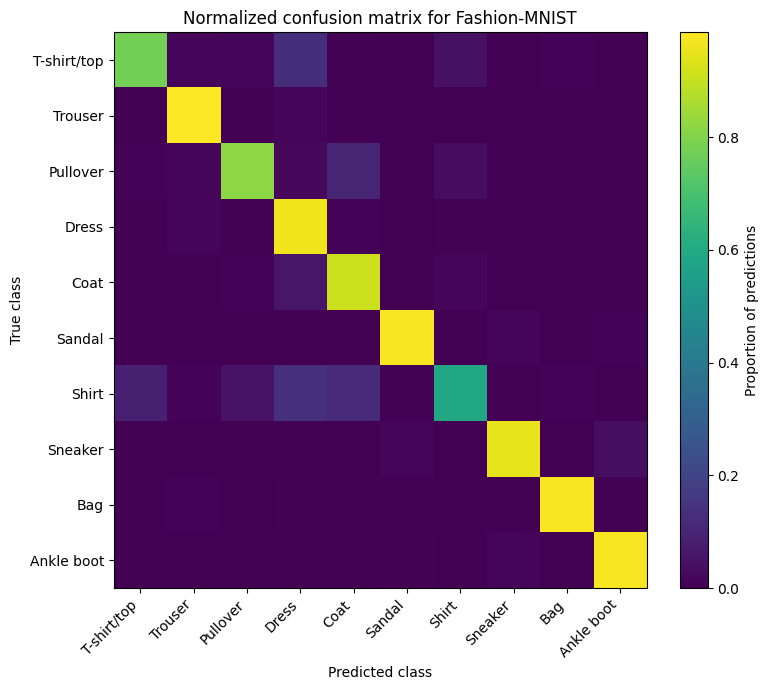

In [114]:
# ============================================================
# Fashion-MNIST confusion matrix
# ============================================================

fashion_y_true, fashion_y_pred = collect_predictions(
    model=fashion_model,
    dataloader=fashion_loaders["test"],
    device=DEVICE
)

fashion_cm = confusion_matrix(
    fashion_y_true,
    fashion_y_pred,
    labels=np.arange(10)
)

fashion_cm_normalized = fashion_cm.astype(float) / fashion_cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8, 7))

plt.imshow(fashion_cm_normalized, interpolation="nearest", aspect="auto")
plt.colorbar(label="Proportion of predictions")

plt.xticks(np.arange(10), fashion_classes, rotation=45, ha="right")
plt.yticks(np.arange(10), fashion_classes)

plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Normalized confusion matrix for Fashion-MNIST")

plt.tight_layout()
plt.show()

The Fashion-MNIST confusion matrix shows that errors are concentrated among visually similar clothing categories. Trouser, Sandal, Bag, and Ankle boot are classified reliably, while Sneaker shows some confusion with Ankle boot. Upper-body garment categories such as T-shirt/top, Pullover, Coat, Dress, and Shirt are more frequently confused. This mirrors the EMNIST analysis: model errors are structured and related to visual similarity rather than being randomly distributed.

In [115]:
# ============================================================
# Top confused Fashion-MNIST class pairs
# ============================================================

fashion_confusion_pairs = []

for true_idx in range(10):
    for pred_idx in range(10):
        if true_idx != pred_idx:
            fashion_confusion_pairs.append({
                "true_class": fashion_classes[true_idx],
                "predicted_class": fashion_classes[pred_idx],
                "count": fashion_cm[true_idx, pred_idx],
                "proportion_within_true_class": fashion_cm_normalized[true_idx, pred_idx]
            })

fashion_top_confusions = (
    pd.DataFrame(fashion_confusion_pairs)
    .sort_values("count", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

fashion_top_confusions

,true_class,predicted_class,count,proportion_within_true_class
0,Shirt,Dress,137,0.137
1,T-shirt/top,Dress,128,0.128
2,Shirt,Coat,120,0.120
3,Pullover,Coat,102,0.102
4,Shirt,T-shirt/top,88,0.088
5,Coat,Dress,59,0.059
6,Shirt,Pullover,50,0.050
7,T-shirt/top,Shirt,45,0.045
8,Sneaker,Ankle boot,37,0.037
9,Pullover,Shirt,32,0.032


The top Fashion-MNIST confusions are concentrated among visually similar clothing categories. The largest error is Shirt → Dress, followed by T-shirt/top → Dress, Shirt → Coat, and Pullover → Coat. These errors mainly involve upper-body clothing classes, which share similar global shape and texture structure. This pattern is consistent with the EMNIST analysis: model errors are not random, but reflect visual similarity between categories.

### Fashion-MNIST psychometric robustness curve

To compare robustness across visual domains, the same Gaussian-noise evaluation is applied to the Fashion-MNIST model. This tests whether object-like visual categories show a similar degradation pattern under increasing sensory noise.

In [116]:
# ============================================================
# Fashion-MNIST psychometric robustness curve
# ============================================================

fashion_noise_levels = [0.00, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40]

fashion_noise_results = []

for noise_std in fashion_noise_levels:
    accuracy, macro_f1 = evaluate_with_gaussian_noise(
        model=fashion_model,
        dataloader=fashion_loaders["test"],
        noise_std=noise_std,
        device=DEVICE,
        num_classes=10
    )
    
    fashion_noise_results.append({
        "noise_std": noise_std,
        "accuracy": accuracy,
        "macro_f1": macro_f1
    })
    
    print(
        f"Noise std: {noise_std:.2f} | "
        f"accuracy: {accuracy:.4f} | "
        f"macro-F1: {macro_f1:.4f}"
    )

fashion_noise_results = pd.DataFrame(fashion_noise_results)
fashion_noise_results

Noise std: 0.00 | accuracy: 0.8924 | macro-F1: 0.8900
Noise std: 0.05 | accuracy: 0.8736 | macro-F1: 0.8713
Noise std: 0.10 | accuracy: 0.8356 | macro-F1: 0.8320
Noise std: 0.15 | accuracy: 0.7658 | macro-F1: 0.7596
Noise std: 0.20 | accuracy: 0.6445 | macro-F1: 0.6273
Noise std: 0.30 | accuracy: 0.4535 | macro-F1: 0.4139
Noise std: 0.40 | accuracy: 0.3503 | macro-F1: 0.2886


,noise_std,accuracy,macro_f1
0,0.00,0.8924,0.890029
1,0.05,0.8736,0.871301
2,0.10,0.8356,0.831970
3,0.15,0.7658,0.759585
4,0.20,0.6445,0.627259
5,0.30,0.4535,0.413942
6,0.40,0.3503,0.288646


The Fashion-MNIST psychometric evaluation shows a gradual decline in performance as Gaussian noise increases. The model remains relatively stable for low noise levels, but performance decreases substantially at stronger noise levels. Compared with EMNIST, Fashion-MNIST starts from a lower clean accuracy and also shows degradation under noise, suggesting that object-like categories are also sensitive to sensory corruption.

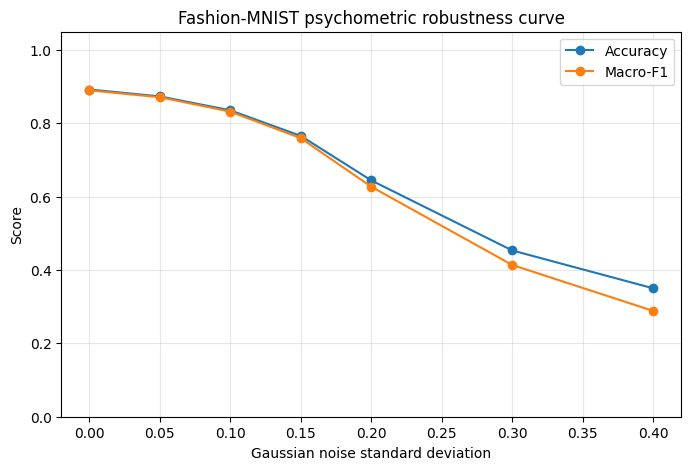

In [117]:
# ============================================================
# Plot Fashion-MNIST psychometric robustness curve
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    fashion_noise_results["noise_std"],
    fashion_noise_results["accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    fashion_noise_results["noise_std"],
    fashion_noise_results["macro_f1"],
    marker="o",
    label="Macro-F1"
)

plt.xlabel("Gaussian noise standard deviation")
plt.ylabel("Score")
plt.title("Fashion-MNIST psychometric robustness curve")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

The Fashion-MNIST psychometric curve shows that performance decreases as Gaussian noise increases. The model is relatively stable for small noise levels, but performance drops more strongly after noise standard deviation 0.15–0.20. This confirms that object-like visual categories are also sensitive to sensory corruption.

### Comparison of robustness across datasets

The EMNIST and Fashion-MNIST psychometric curves are compared to evaluate whether symbolic letter concepts and object-like fashion categories show similar degradation patterns under increasing sensory noise.

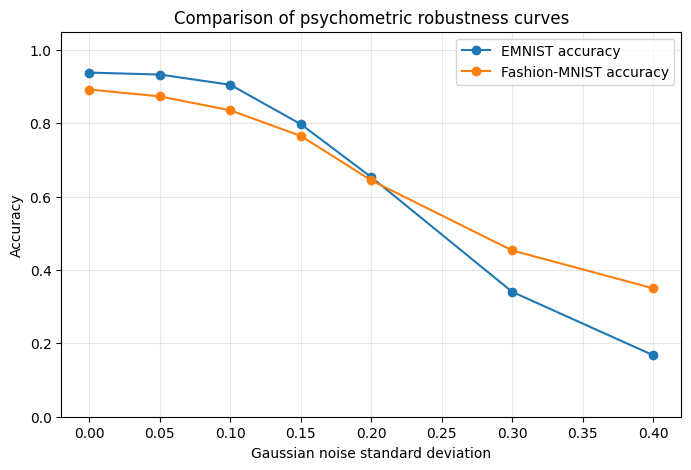

In [118]:
# ============================================================
# Compare EMNIST and Fashion-MNIST psychometric curves
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    emnist_noise_results["noise_std"],
    emnist_noise_results["accuracy"],
    marker="o",
    label="EMNIST accuracy"
)

plt.plot(
    fashion_noise_results["noise_std"],
    fashion_noise_results["accuracy"],
    marker="o",
    label="Fashion-MNIST accuracy"
)

plt.xlabel("Gaussian noise standard deviation")
plt.ylabel("Accuracy")
plt.title("Comparison of psychometric robustness curves")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

The comparison shows that both datasets exhibit a psychometric-like degradation pattern: accuracy decreases as input noise increases. EMNIST starts from a higher clean accuracy, while Fashion-MNIST remains slightly more stable at the highest noise levels. One possible explanation is that Fashion-MNIST categories often contain larger global object shapes, whereas EMNIST letter recognition depends more strongly on fine stroke structure. Overall, both domains show that the learned visual concepts are useful under clean conditions but sensitive to sensory corruption.

In [119]:
# ============================================================
# Summary comparison between EMNIST and Fashion-MNIST
# ============================================================

summary_results = pd.DataFrame([
    {
        "dataset": "EMNIST Letters",
        "num_classes": 26,
        "test_accuracy": test_accuracy,
        "test_macro_f1": test_f1,
        "main_error_pattern": "I/L and G/Q confusions",
        "role": "Main symbolic visual-concept dataset"
    },
    {
        "dataset": "Fashion-MNIST",
        "num_classes": 10,
        "test_accuracy": fashion_test_accuracy,
        "test_macro_f1": fashion_test_f1,
        "main_error_pattern": "Upper-body clothing confusions",
        "role": "Secondary object-like comparison dataset"
    }
])

summary_results

,dataset,num_classes,test_accuracy,test_macro_f1,main_error_pattern,role
0,EMNIST Letters,26,0.938558,0.938239,I/L and G/Q confusions,Main symbolic visual-concept dataset
1,Fashion-MNIST,10,0.892400,0.890029,Upper-body clothing confusions,Secondary object-like comparison dataset


## Cognitive Interpretation

Overall, the results show that the CNN gradually transforms the input images into more useful visual representations.

At the beginning, the model receives only low-level pixel information. In the early convolutional layers, it starts detecting simple local visual patterns such as strokes, edges, and contrast changes. In deeper layers, these local patterns are combined into representations that are more informative for recognizing letters and object-like categories.

The linear read-out results support this interpretation. When a linear classifier is trained directly on raw pixels, performance is clearly lower. When the same classifier is trained on deeper CNN features, accuracy increases strongly. This suggests that the network is not simply memorizing images, but reorganizing the input into a feature space where categories become easier to separate.

The confusion matrix and clustering results also show meaningful structure. In EMNIST, letters such as I/L and G/Q appear close in the learned representation space and are also among the most frequent confusion pairs. A similar pattern appears in Fashion-MNIST, where many errors occur between visually similar clothing categories. This suggests that the model’s internal representations capture meaningful visual relations between categories.

However, the robustness results reveal an important limitation. The model performs well on clean test images, but accuracy decreases when Gaussian noise is added and drops even more under adversarial perturbations. This means that high classification accuracy alone does not guarantee robust visual concept learning. The CNN learns useful representations for classification, but its decision boundaries can still be fragile in ways that differ from human perception.

---

## Summary of Findings

This project investigated visual concept learning using convolutional neural networks on EMNIST Letters and Fashion-MNIST.

The main findings are:

1. **Model selection**  
   Among the tested configurations, the baseline CNN achieved the best validation performance. Increasing model width or adding stronger regularization did not improve the result, suggesting that the baseline architecture was already sufficient for this task.

2. **Final EMNIST performance**  
   The selected model achieved approximately 93.9% test accuracy and 93.8% macro-F1 on EMNIST Letters, showing strong overall performance across the 26 letter classes.

3. **Structured errors**  
   The confusion matrix showed that errors were not random. The most frequent mistakes occurred between visually similar handwritten letters, especially I/L and G/Q.

4. **Layer-wise disentanglement**  
   Linear read-out analysis showed that class separability improved from raw pixels to deeper CNN blocks. This supports the idea that the network progressively transforms low-level sensory input into more useful and more separable visual concept representations.

5. **Internal representation geometry**  
   Representational similarity analysis and hierarchical clustering showed meaningful relationships between letter classes. Some clusters, such as I–L and G–Q, matched the confusion patterns observed in the classification results.

6. **Noise and adversarial robustness**  
   Psychometric curves showed that performance decreased as Gaussian noise increased. FGSM adversarial attacks produced an even sharper drop, showing that high accuracy on clean images does not necessarily imply robust visual perception. A compact adversarial fine-tuning experiment improved robustness against some perturbation levels.

7. **Secondary validation on Fashion-MNIST**  
   Fashion-MNIST showed similar structured error patterns and also degraded under noise. Its lower clean accuracy suggests that object-like clothing categories were more difficult for this compact CNN than handwritten letters.

---

## Limitations

This project has several limitations.

First, the models used here are relatively small CNNs trained on 28 × 28 grayscale images. Therefore, the results may not directly generalize to larger and more complex natural-image datasets.

Second, Fashion-MNIST was used mainly as a secondary comparison dataset. The full representation-analysis pipeline was not repeated with the same depth as for EMNIST, so the comparison between symbolic and object-like categories remains limited.

Third, the adversarial analysis focused on FGSM. This provides a useful first evaluation of adversarial sensitivity, but stronger iterative attacks could provide a more complete robustness assessment.

Finally, the project connects model behavior to concepts such as perceptual similarity, hierarchical processing, and robustness. However, no direct human behavioral data were collected. Therefore, the CNN should be interpreted as a computational analogy for some aspects of visual concept learning, not as a biologically faithful model of the human visual system.

---

## Conclusion

The results show that convolutional neural networks can learn hierarchical visual concept representations from both symbolic and object-like visual categories.

In EMNIST Letters, deeper CNN layers produced increasingly linearly separable representations, and the internal geometry of the learned features reflected meaningful similarities between letter classes. Errors were structured around visually similar categories rather than being uniformly distributed.

At the same time, the robustness analyses showed that these learned visual concepts remain sensitive to sensory corruption and adversarial perturbations. This highlights an important distinction between classification accuracy and robust visual concept learning.

Overall, the project supports the view that CNNs provide a useful computational model for studying hierarchical visual representation learning, while also showing important limitations when compared with robust human-like perception.